# helper function

In [1]:
import torch
from torch import nn
from torchvision import datasets,transforms
from torch.utils.data import random_split

## Data augmentation

In [2]:
def transform(img_size):
  train_transforms = transforms.Compose([transforms.Resize((img_size,img_size)),  
                transforms.RandomHorizontalFlip(), 
                transforms.RandomRotation(5),     
                transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5), 
                transforms.ToTensor(), 
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),])
  test_transforms = transforms.Compose([transforms.Resize((img_size,img_size)),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),])
  return train_transforms, test_transforms

## Load data : CIFAR10

In [3]:
def load_CIFAR10(train_transforms, test_transforms):
  dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms) 
  test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)
  
  train_dataset, val_dataset = random_split(dataset,[0.8, 0.2])

  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=12)
  val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=100, shuffle=True, num_workers=12)
  test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=12)
  return train_loader, val_loader, test_loader

## Train

In [4]:
def train(network,optimizer,num_epochs,train_loader,val_loader):
  train_losses = []
  train_corrects = []
  val_losses = []
  val_corrects = []
  for e in range(num_epochs):
      print('epoch {}:'.format(e+1))

      network.train()
      train_iter = iter(train_loader)
      train_loss = 0
      train_correct = 0
      for i in range(len(train_loader)):        
          x, y = next(train_iter)
          x_gpu = x.to('cuda')
          y_gpu = y.to('cuda')

          pred = network(x_gpu)

          pred_y = pred.argmax(dim=1, keepdim=True)                                 
          train_correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()
          loss = nn.CrossEntropyLoss()(pred, y_gpu)        
          train_loss += loss.item()

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      train_loss = train_loss/len(train_loader)
      train_correct = train_correct/len(train_loader)
      train_losses.append(train_loss)
      train_corrects.append(train_correct)
      print('training loss: {}, accuracy {} '.format(train_loss, train_correct))

      network.eval()
      val_iter = iter(val_loader)
      val_loss = 0
      val_correct = 0    
      for i in range(len(val_loader)):
          x, y = next(val_iter)
          x_gpu = x.to('cuda')
          y_gpu = y.to('cuda')

          pred = network(x_gpu)

          pred_y = pred.argmax(dim=1, keepdim=True)                                         
          val_correct += pred_y.eq(y_gpu.view_as(pred_y)).sum().item()        
          loss = nn.CrossEntropyLoss()(pred, y_gpu)
          val_loss += loss.item()

      val_loss = val_loss/len(val_loader)
      val_correct = val_correct/ len(val_loader)
      val_losses.append(val_loss)
      val_corrects.append(val_correct)
      print('validation loss: {}, validation accuracy {} '.format(val_loss, val_correct))
  return train_losses,val_losses,train_corrects,val_corrects

## Evaluate

In [5]:
def evaluate(network, data_loader):
    network.eval()
    iterator = iter(data_loader)    
    correct = 0
    for i in range(len(iterator)):        
        x, y = next(iterator)
        x_gpu = x.to('cuda')
        y_gpu = y.to('cuda')
        pred = network(x_gpu).argmax(dim=1, keepdim=True) 
        correct += pred.eq(y_gpu.view_as(pred)).sum().item()               
    return correct / len(data_loader)

# CNN

In [9]:
import matplotlib.pyplot as plt
from torch.optim import Adam

## LeNet

In [44]:
class LeNet(nn.Module):
    def __init__(self):
      super().__init__()
      self.conv1 = nn.Sequential(nn.Conv2d(3, 16, 5),
                     nn.MaxPool2d(2, 2))
      self.conv2 = nn.Sequential(nn.Conv2d(16, 32, 5),
                     nn.MaxPool2d(2, 2))
      self.fc1 = nn.Linear(32*5*5, 120)
      self.fc2 = nn.Linear(120, 84)
      self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
      x = self.conv1(x)
      x = self.conv2(x)
      x = x.view(x.size(0),-1) # flatten
      x = self.fc1(x)
      x = self.fc2(x)
      x = self.fc3(x)
      return x

In [45]:
Le_inChannels = 32
Le_train_transforms, Le_test_transforms = transform(Le_inChannels)
Le_train_loader, Le_val_loader, Le_test_loader = load_CIFAR10(Le_train_transforms, Le_test_transforms)

Files already downloaded and verified
Files already downloaded and verified


### lr=0.001, epoch=100

In [46]:
LeNet1 = LeNet().to('cuda')
LeNet1_optim = Adam(LeNet1.parameters(), lr=0.001)
LeNet1_train_losses,LeNet1_val_losses,LeNet1_train_corrects,LeNet1_val_corrects = train(LeNet1,LeNet1_optim,100,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.689931661784649, accuracy 40.5325 
validation loss: 1.5114068615436553, validation accuracy 48.32 
epoch 2:
training loss: 1.4352113923430443, accuracy 51.0525 
validation loss: 1.3928419315814973, validation accuracy 52.65 
epoch 3:
training loss: 1.3544575050473213, accuracy 54.4625 
validation loss: 1.3532048058509827, validation accuracy 54.98 
epoch 4:
training loss: 1.3039215405285358, accuracy 56.3575 
validation loss: 1.318552601337433, validation accuracy 56.42 
epoch 5:
training loss: 1.2776105873286725, accuracy 57.2625 
validation loss: 1.309761129617691, validation accuracy 56.69 
epoch 6:
training loss: 1.2527107733488083, accuracy 58.2575 
validation loss: 1.2687920814752578, validation accuracy 57.51 
epoch 7:
training loss: 1.2249056167900563, accuracy 59.66 
validation loss: 1.3017349553108215, validation accuracy 56.68 
epoch 8:
training loss: 1.2155004413425923, accuracy 59.63 
validation loss: 1.2361130225658417, validation accuracy 59.05 

### lr=0.001, epoch=100

In [ ]:
LeNet2 = LeNet().to('cuda')
LeNet2_optim = Adam(LeNet2.parameters(), lr=0.001)
LeNet2_train_losses,LeNet2_val_losses,LeNet2_train_corrects,LeNet2_val_corrects = train(LeNet2,LeNet2_optim,100,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.7078472432494163, accuracy 40.245 
validation loss: 1.5247513163089752, validation accuracy 46.61 
epoch 2:
training loss: 1.4702193620800972, accuracy 49.3375 
validation loss: 1.4398216533660888, validation accuracy 50.97 
epoch 3:
training loss: 1.372453546524048, accuracy 53.7375 
validation loss: 1.351650936603546, validation accuracy 54.85 
epoch 4:
training loss: 1.3252415838837623, accuracy 55.16 
validation loss: 1.3462542629241943, validation accuracy 55.01 
epoch 5:
training loss: 1.2808786725997925, accuracy 57.2525 
validation loss: 1.2903254520893097, validation accuracy 57.65 
epoch 6:
training loss: 1.248710949420929, accuracy 58.385 
validation loss: 1.2812408190965652, validation accuracy 57.33 
epoch 7:
training loss: 1.2326558348536492, accuracy 59.1625 
validation loss: 1.2578809529542923, validation accuracy 57.94 
epoch 8:
training loss: 1.2183905270695687, accuracy 59.595 
validation loss: 1.2333143216371536, validation accuracy 58.85 


### lr=0.001, epoch=100

In [ ]:
LeNet3 = LeNet().to('cuda')
LeNet3_optim = Adam(LeNet3.parameters(), lr=0.001)
LeNet3_train_losses,LeNet3_val_losses,LeNet3_train_corrects,LeNet3_val_corrects = train(LeNet3,LeNet3_optim,100,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.7031271624565125, accuracy 40.4125 
validation loss: 1.5200518476963043, validation accuracy 47.68 
epoch 2:
training loss: 1.464022136926651, accuracy 50.01 
validation loss: 1.4010355973243713, validation accuracy 53.06 
epoch 3:
training loss: 1.3713832780718804, accuracy 53.9 
validation loss: 1.369476456642151, validation accuracy 54.39 
epoch 4:
training loss: 1.3129767566919326, accuracy 55.8875 
validation loss: 1.3007574254274368, validation accuracy 55.78 
epoch 5:
training loss: 1.2830345660448075, accuracy 57.3 
validation loss: 1.3096395725011825, validation accuracy 56.79 
epoch 6:
training loss: 1.247692782431841, accuracy 58.8375 
validation loss: 1.279198290705681, validation accuracy 58.38 
epoch 7:
training loss: 1.2319985102117061, accuracy 59.275 
validation loss: 1.2864238512516022, validation accuracy 57.94 
epoch 8:
training loss: 1.2050057366490363, accuracy 60.015 
validation loss: 1.2811967813968659, validation accuracy 57.55 
epoch 

### lr=0.0001, epoch=100

In [ ]:
LeNet4 = LeNet().to('cuda')
LeNet4_optim = Adam(LeNet4.parameters(), lr=0.0001)
LeNet4_train_losses,LeNet4_val_losses,LeNet4_train_corrects,LeNet4_val_corrects = train(LeNet4,LeNet4_optim,100,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.9783718770742416, accuracy 30.0775 
validation loss: 1.838516901731491, validation accuracy 36.18 
epoch 2:
training loss: 1.7621007439494134, accuracy 38.99 
validation loss: 1.7188229441642762, validation accuracy 40.27 
epoch 3:
training loss: 1.661381778717041, accuracy 42.5675 
validation loss: 1.631561220884323, validation accuracy 43.85 
epoch 4:
training loss: 1.5987564891576767, accuracy 44.95 
validation loss: 1.5851290345191955, validation accuracy 45.38 
epoch 5:
training loss: 1.559736931324005, accuracy 46.455 
validation loss: 1.5529301905632018, validation accuracy 46.71 
epoch 6:
training loss: 1.526412059366703, accuracy 47.92 
validation loss: 1.5187091934680939, validation accuracy 47.61 
epoch 7:
training loss: 1.5024671268463134, accuracy 48.8025 
validation loss: 1.5181836152076722, validation accuracy 47.35 
epoch 8:
training loss: 1.4829023721814156, accuracy 49.7525 
validation loss: 1.4730181801319122, validation accuracy 49.99 
epoc

### lr=0.0001, epoch=100

In [ ]:
LeNet5 = LeNet().to('cuda')
LeNet5_optim = Adam(LeNet5.parameters(), lr=0.0001)
LeNet5_train_losses,LeNet5_val_losses,LeNet5_train_corrects,LeNet5_val_corrects = train(LeNet5,LeNet5_optim,100,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.974348819255829, accuracy 29.8475 
validation loss: 1.8377700936794281, validation accuracy 35.54 
epoch 2:
training loss: 1.7531326749920846, accuracy 39.37 
validation loss: 1.695134619474411, validation accuracy 40.96 
epoch 3:
training loss: 1.6481998637318611, accuracy 42.765 
validation loss: 1.6311971354484558, validation accuracy 43.52 
epoch 4:
training loss: 1.5996693563461304, accuracy 44.6 
validation loss: 1.5901148331165313, validation accuracy 44.35 
epoch 5:
training loss: 1.5681998145580291, accuracy 45.775 
validation loss: 1.563158813714981, validation accuracy 45.43 
epoch 6:
training loss: 1.5309553459286689, accuracy 47.1 
validation loss: 1.5293928515911102, validation accuracy 47.64 
epoch 7:
training loss: 1.512670870423317, accuracy 48.105 
validation loss: 1.5184519052505494, validation accuracy 48.79 
epoch 8:
training loss: 1.4904233986139297, accuracy 48.9075 
validation loss: 1.494749881029129, validation accuracy 49.31 
epoch 9:

### lr=0.0001, epoch=100

In [ ]:
LeNet6 = LeNet().to('cuda')
LeNet6_optim = Adam(LeNet6.parameters(), lr=0.0001)
LeNet6_train_losses,LeNet6_val_losses,LeNet6_train_corrects,LeNet6_val_corrects = train(LeNet6,LeNet6_optim,100,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.9889500430226326, accuracy 29.26 
validation loss: 1.836709121465683, validation accuracy 35.84 
epoch 2:
training loss: 1.754436889886856, accuracy 39.375 
validation loss: 1.7029607236385345, validation accuracy 41.61 
epoch 3:
training loss: 1.661400511264801, accuracy 42.91 
validation loss: 1.636294001340866, validation accuracy 43.28 
epoch 4:
training loss: 1.5919899550080299, accuracy 45.38 
validation loss: 1.5685585355758667, validation accuracy 45.8 
epoch 5:
training loss: 1.5456269836425782, accuracy 47.1025 
validation loss: 1.5367495799064637, validation accuracy 46.88 
epoch 6:
training loss: 1.5150832349061967, accuracy 48.0275 
validation loss: 1.5121611857414246, validation accuracy 47.69 
epoch 7:
training loss: 1.4897386181354522, accuracy 49.3775 
validation loss: 1.4712653648853302, validation accuracy 50.25 
epoch 8:
training loss: 1.4655106300115586, accuracy 50.0825 
validation loss: 1.4610349917411805, validation accuracy 50.58 
epoc

### loss/acc graph

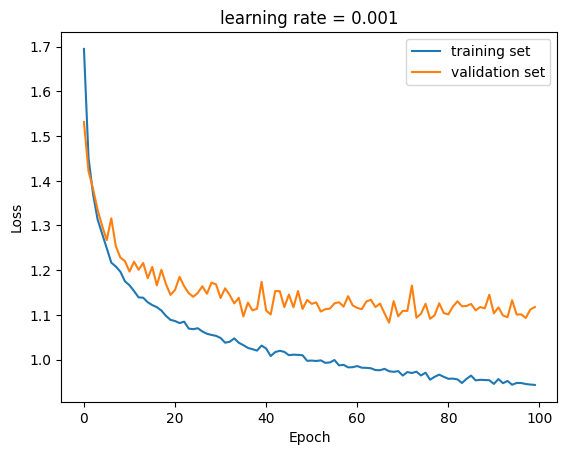

In [ ]:
plt.plot(LeNet1_train_losses, label='training set')
plt.plot(LeNet1_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

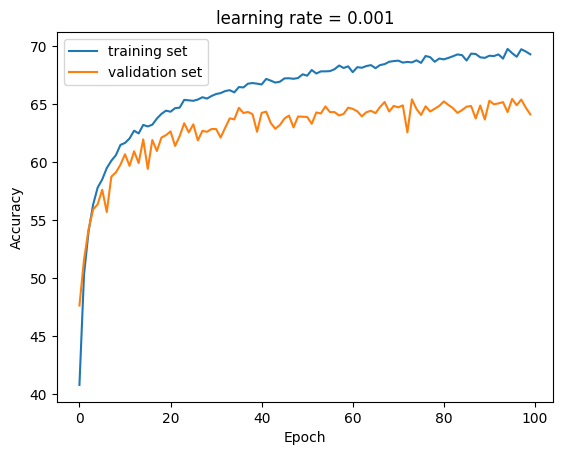

In [ ]:
plt.plot(LeNet1_train_corrects, label='training set')
plt.plot(LeNet1_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

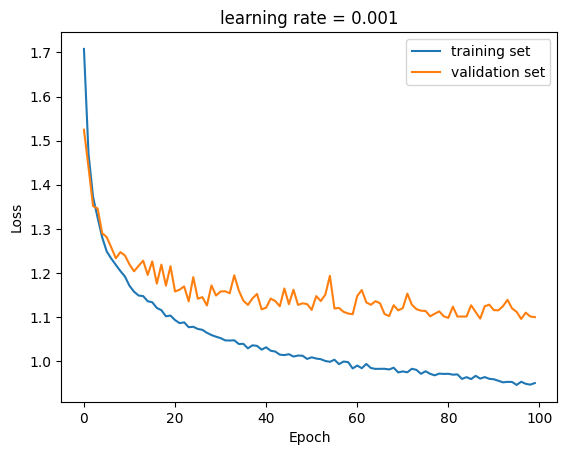

In [ ]:
plt.plot(LeNet2_train_losses, label='training set')
plt.plot(LeNet2_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

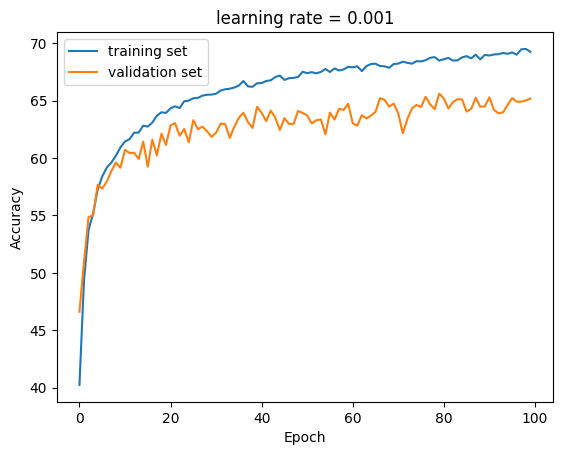

In [ ]:
plt.plot(LeNet2_train_corrects, label='training set')
plt.plot(LeNet2_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

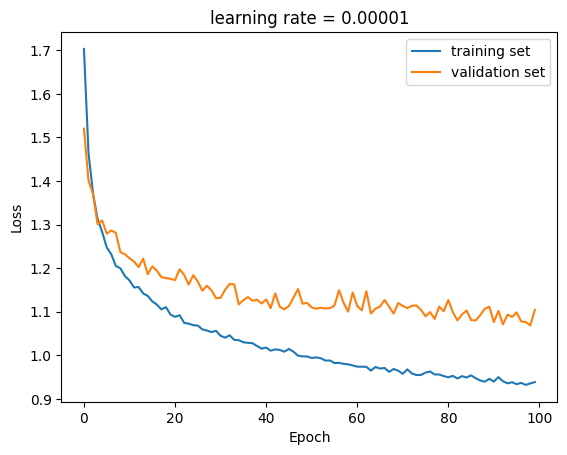

In [ ]:
plt.plot(LeNet3_train_losses, label='training set')
plt.plot(LeNet3_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.00001')
plt.legend()

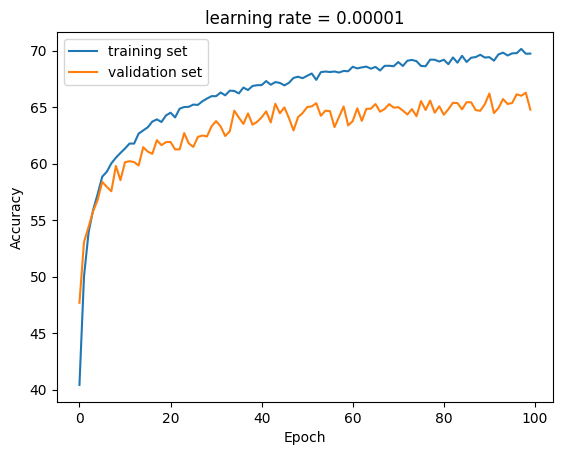

In [ ]:
plt.plot(LeNet3_train_corrects, label='training set')
plt.plot(LeNet3_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.00001')
plt.legend()

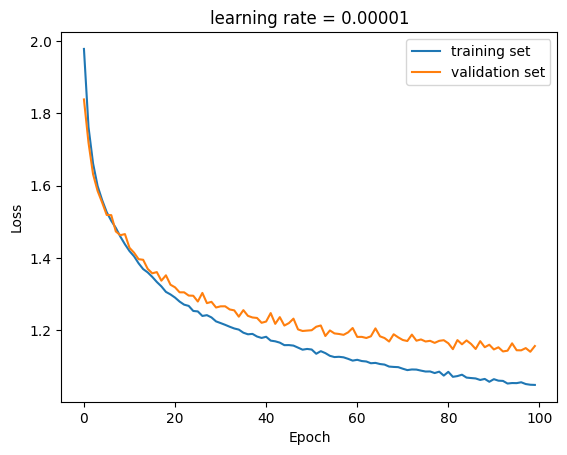

In [ ]:
plt.plot(LeNet4_train_losses, label='training set')
plt.plot(LeNet4_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.00001')
plt.legend()

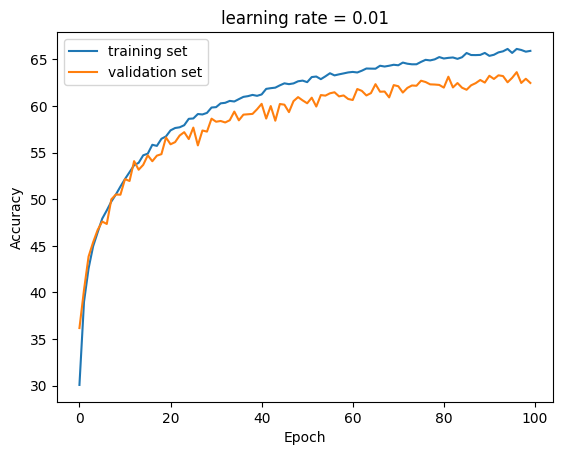

In [ ]:
plt.plot(LeNet4_train_corrects, label='training set')
plt.plot(LeNet4_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

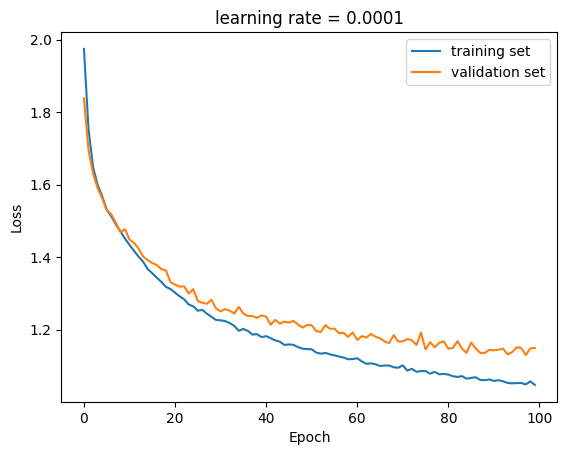

In [ ]:
plt.plot(LeNet5_train_losses, label='training set')
plt.plot(LeNet5_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

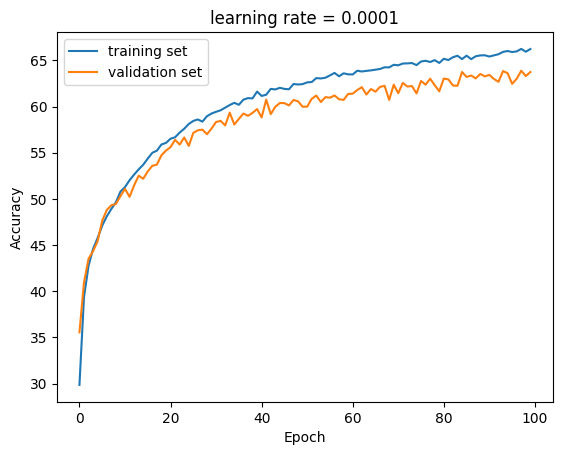

In [ ]:
plt.plot(LeNet5_train_corrects, label='training set')
plt.plot(LeNet5_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

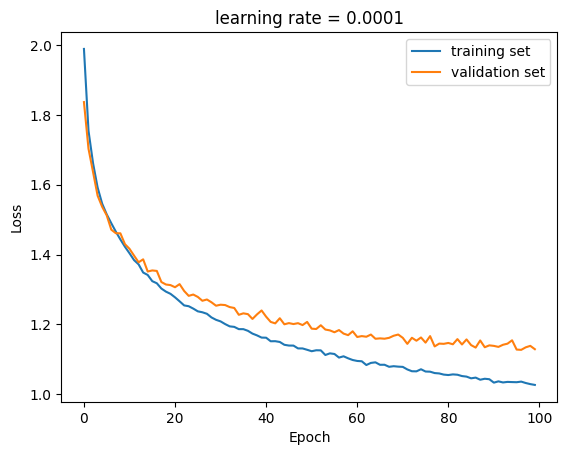

In [ ]:
plt.plot(LeNet6_train_losses, label='training set')
plt.plot(LeNet6_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

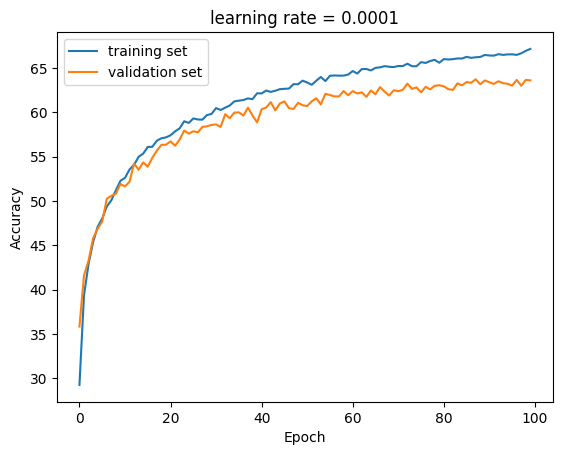

In [ ]:
plt.plot(LeNet6_train_corrects, label='training set')
plt.plot(LeNet6_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

### test acc

In [ ]:
print(evaluate(LeNet1, Le_test_loader))
print(evaluate(LeNet2, Le_test_loader))
print(evaluate(LeNet3, Le_test_loader))
print(evaluate(LeNet4, Le_test_loader))
print(evaluate(LeNet5, Le_test_loader))
print(evaluate(LeNet6, Le_test_loader))

66.93
67.55
68.02
65.76
65.85
65.97


## AlexNet

In [47]:
from torchvision.models import alexnet,AlexNet_Weights

In [48]:
Alex_inChannels = 256
Alex_train_transforms, Alex_test_transforms = transform(Alex_inChannels)
Alex_train_loader, Alex_val_loader, Alex_test_loader = load_CIFAR10(Alex_train_transforms, Alex_test_transforms)

Files already downloaded and verified
Files already downloaded and verified


### lr=0.001, epoch=100

In [9]:
lr = 0.0001
epoch = 100
AlexNet1 = alexnet(weights = AlexNet_Weights.IMAGENET1K_V1)
AlexNet1.classifier[4] = nn.Linear(4096,1024)
AlexNet1.classifier[6] = nn.Linear(1024,10)
AlexNet1.to('cuda')
for param in AlexNet1.parameters():
    param.requires_grad = False
for param in AlexNet1.classifier.parameters():
    param.requires_grad = True 
AlexNet1_optim = Adam(AlexNet1.parameters(), lr=lr)
AlexNet1_train_losses,AlexNet1_val_losses,AlexNet1_train_corrects,AlexNet1_val_corrects = train(AlexNet1,AlexNet1_optim,epoch,Alex_train_loader,Alex_val_loader)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:08<00:00, 27.6MB/s]


epoch 1:
training loss: 1.0412784823775292, accuracy 63.33 
validation loss: 0.8267396700382232, validation accuracy 70.97 
epoch 2:
training loss: 0.8267598029971123, accuracy 70.9125 
validation loss: 0.7313655212521553, validation accuracy 74.59 
epoch 3:
training loss: 0.770681399255991, accuracy 73.1725 
validation loss: 0.6871887618303298, validation accuracy 76.25 
epoch 4:
training loss: 0.7316860025376082, accuracy 74.3925 
validation loss: 0.648144083917141, validation accuracy 77.71 
epoch 5:
training loss: 0.7020336979627609, accuracy 75.405 
validation loss: 0.6311902922391891, validation accuracy 77.75 
epoch 6:
training loss: 0.6882579324394464, accuracy 75.8825 
validation loss: 0.6254338231682778, validation accuracy 78.02 
epoch 7:
training loss: 0.659417776465416, accuracy 77.02 
validation loss: 0.6130934771895409, validation accuracy 78.71 
epoch 8:
training loss: 0.6479759375751019, accuracy 76.9975 
validation loss: 0.6143790984153747, validation accuracy 78.62 


### lr=0.001, epoch=100

In [10]:
lr = 0.001
epoch = 100
AlexNet2 = alexnet(weights = AlexNet_Weights.IMAGENET1K_V1)
AlexNet2.classifier[4] = nn.Linear(4096,1024)
AlexNet2.classifier[6] = nn.Linear(1024,10)
AlexNet2.to('cuda')
for param in AlexNet2.parameters():
    param.requires_grad = False
for param in AlexNet2.classifier.parameters():
    param.requires_grad = True 
AlexNet2_optim = Adam(AlexNet2.parameters(), lr=lr)
AlexNet2_train_losses,AlexNet2_val_losses,AlexNet2_train_corrects,AlexNet2_val_corrects = train(AlexNet2,AlexNet2_optim,epoch,Alex_train_loader,Alex_val_loader)

epoch 1:
training loss: 1.091178328692913, accuracy 61.435 
validation loss: 0.8110190534591675, validation accuracy 71.71 
epoch 2:
training loss: 0.913741055727005, accuracy 68.11 
validation loss: 0.7878400194644928, validation accuracy 73.24 
epoch 3:
training loss: 0.8629175713658332, accuracy 70.0125 
validation loss: 0.738908651471138, validation accuracy 74.67 
epoch 4:
training loss: 0.8369191952049733, accuracy 70.785 
validation loss: 0.7212933832406998, validation accuracy 74.8 
epoch 5:
training loss: 0.8122360856831073, accuracy 71.915 
validation loss: 0.6810499441623687, validation accuracy 77.06 
epoch 6:
training loss: 0.7976388373225928, accuracy 72.4775 
validation loss: 0.6930285030603409, validation accuracy 76.95 
epoch 7:
training loss: 0.7800936995446682, accuracy 72.935 
validation loss: 0.6700328329205513, validation accuracy 77.29 
epoch 8:
training loss: 0.767292782664299, accuracy 73.6675 
validation loss: 0.6765449088811875, validation accuracy 77.35 
epo

### lr=0.01, epoch=100

In [12]:
lr = 0.001
epoch = 100
AlexNet3 = alexnet(weights = AlexNet_Weights.IMAGENET1K_V1)
AlexNet3.classifier[4] = nn.Linear(4096,1024)
AlexNet3.classifier[6] = nn.Linear(1024,10)
AlexNet3.to('cuda')
for param in AlexNet3.parameters():
    param.requires_grad = False
for param in AlexNet3.classifier.parameters():
    param.requires_grad = True 
AlexNet3_optim = Adam(AlexNet3.parameters(), lr=lr)
AlexNet3_train_losses,AlexNet3_val_losses,AlexNet3_train_corrects,AlexNet3_val_corrects = train(AlexNet3,AlexNet3_optim,epoch,Alex_train_loader,Alex_val_loader)

epoch 1:
training loss: 1.0972758431732654, accuracy 61.6075 
validation loss: 0.8084126168489456, validation accuracy 71.6 
epoch 2:
training loss: 0.9045642346143723, accuracy 68.4075 
validation loss: 0.7895524954795837, validation accuracy 72.64 
epoch 3:
training loss: 0.8708115017414093, accuracy 69.8475 
validation loss: 0.769739865064621, validation accuracy 73.19 
epoch 4:
training loss: 0.8324918591976166, accuracy 71.25 
validation loss: 0.7103913843631744, validation accuracy 75.31 
epoch 5:
training loss: 0.8118124476075173, accuracy 71.595 
validation loss: 0.7267636513710022, validation accuracy 74.11 
epoch 6:
training loss: 0.7869211508333683, accuracy 72.765 
validation loss: 0.6817611384391785, validation accuracy 76.66 
epoch 7:
training loss: 0.7789813639223575, accuracy 72.88 
validation loss: 0.6995585998892784, validation accuracy 75.74 
epoch 8:
training loss: 0.7691252413392067, accuracy 73.1775 
validation loss: 0.6834917548298836, validation accuracy 76.7 
e

### lr=0.01, epoch=100

In [13]:
lr = 0.001
epoch = 100
AlexNet4 = alexnet(weights = AlexNet_Weights.IMAGENET1K_V1)
AlexNet4.classifier[4] = nn.Linear(4096,1024)
AlexNet4.classifier[6] = nn.Linear(1024,10)
AlexNet4.to('cuda')
for param in AlexNet4.parameters():
    param.requires_grad = False
for param in AlexNet4.classifier.parameters():
    param.requires_grad = True 
AlexNet4_optim = Adam(AlexNet4.parameters(), lr=lr)
AlexNet4_train_losses,AlexNet4_val_losses,AlexNet4_train_corrects,AlexNet4_val_corrects = train(AlexNet4,AlexNet4_optim,epoch,Alex_train_loader,Alex_val_loader)

epoch 1:
training loss: 1.1201146513223648, accuracy 60.995 
validation loss: 0.8203302001953126, validation accuracy 71.54 
epoch 2:
training loss: 0.9212392693758011, accuracy 67.9575 
validation loss: 0.7834509819746017, validation accuracy 72.99 
epoch 3:
training loss: 0.8632329295575619, accuracy 69.7725 
validation loss: 0.7354491955041885, validation accuracy 74.98 
epoch 4:
training loss: 0.8364738684892654, accuracy 70.7975 
validation loss: 0.7132405596971512, validation accuracy 75.67 
epoch 5:
training loss: 0.8173775901645421, accuracy 71.5275 
validation loss: 0.7161190843582154, validation accuracy 76.15 
epoch 6:
training loss: 0.8046145817637443, accuracy 71.825 
validation loss: 0.6833939862251281, validation accuracy 76.67 
epoch 7:
training loss: 0.7810913317650556, accuracy 72.9775 
validation loss: 0.6763643762469291, validation accuracy 76.72 
epoch 8:
training loss: 0.7722637784481049, accuracy 73.27 
validation loss: 0.6722058150172233, validation accuracy 77.

### lr=0.0001, epoch=100

In [14]:
lr = 0.0001
epoch = 100
AlexNet5 = alexnet(weights = AlexNet_Weights.IMAGENET1K_V1)
AlexNet5.classifier[4] = nn.Linear(4096,1024)
AlexNet5.classifier[6] = nn.Linear(1024,10)
AlexNet5.to('cuda')
for param in AlexNet5.parameters():
    param.requires_grad = False
for param in AlexNet5.classifier.parameters():
    param.requires_grad = True 
AlexNet5_optim = Adam(AlexNet5.parameters(), lr=lr)
AlexNet5_train_losses,AlexNet5_val_losses,AlexNet5_train_corrects,AlexNet5_val_corrects = train(AlexNet5,AlexNet5_optim,epoch,Alex_train_loader,Alex_val_loader)

epoch 1:
training loss: 1.0398443920910359, accuracy 63.5425 
validation loss: 0.7932344019412995, validation accuracy 71.67 
epoch 2:
training loss: 0.8323166789859533, accuracy 70.6475 
validation loss: 0.7102958709001541, validation accuracy 75.54 
epoch 3:
training loss: 0.7660573484748602, accuracy 72.965 
validation loss: 0.6780471274256706, validation accuracy 76.09 
epoch 4:
training loss: 0.7338604070991278, accuracy 74.1025 
validation loss: 0.660872186422348, validation accuracy 76.82 
epoch 5:
training loss: 0.7080797192454338, accuracy 74.9875 
validation loss: 0.6265492558479309, validation accuracy 78.27 
epoch 6:
training loss: 0.6742450405657291, accuracy 76.1975 
validation loss: 0.6254013779759408, validation accuracy 78.14 
epoch 7:
training loss: 0.6639343222975731, accuracy 76.525 
validation loss: 0.6022797173261643, validation accuracy 78.41 
epoch 8:
training loss: 0.6450766506791115, accuracy 77.255 
validation loss: 0.6089252135157586, validation accuracy 78.

### lr=0.0001, epoch=100

In [49]:
lr = 0.0001
epoch = 100
AlexNet6 = alexnet(weights = AlexNet_Weights.IMAGENET1K_V1)
AlexNet6.classifier[4] = nn.Linear(4096,1024)
AlexNet6.classifier[6] = nn.Linear(1024,10)
AlexNet6.to('cuda')
for param in AlexNet6.parameters():
    param.requires_grad = False
for param in AlexNet6.classifier.parameters():
    param.requires_grad = True 
AlexNet6_optim = Adam(AlexNet6.parameters(), lr=lr)
AlexNet6_train_losses,AlexNet6_val_losses,AlexNet6_train_corrects,AlexNet6_val_corrects = train(AlexNet6,AlexNet6_optim,epoch,Alex_train_loader,Alex_val_loader)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:00<00:00, 248MB/s]


epoch 1:
training loss: 1.0388123559951783, accuracy 63.2425 
validation loss: 0.7754073828458786, validation accuracy 73.02 
epoch 2:
training loss: 0.8339195290207863, accuracy 70.635 
validation loss: 0.6903208813071251, validation accuracy 76.19 
epoch 3:
training loss: 0.7728504984080792, accuracy 72.87 
validation loss: 0.6770756503939629, validation accuracy 76.23 
epoch 4:
training loss: 0.7297159370779991, accuracy 74.3325 
validation loss: 0.6615855753421783, validation accuracy 77.04 
epoch 5:
training loss: 0.6991532911360264, accuracy 75.2175 
validation loss: 0.6334054282307625, validation accuracy 78.1 
epoch 6:
training loss: 0.690321154743433, accuracy 75.91 
validation loss: 0.6215487563610077, validation accuracy 78.65 
epoch 7:
training loss: 0.6557312750816345, accuracy 76.7375 
validation loss: 0.6020144546031951, validation accuracy 79.54 
epoch 8:
training loss: 0.6444803983718157, accuracy 77.285 
validation loss: 0.5926653999090195, validation accuracy 79.4 
e

### loss/acc graph

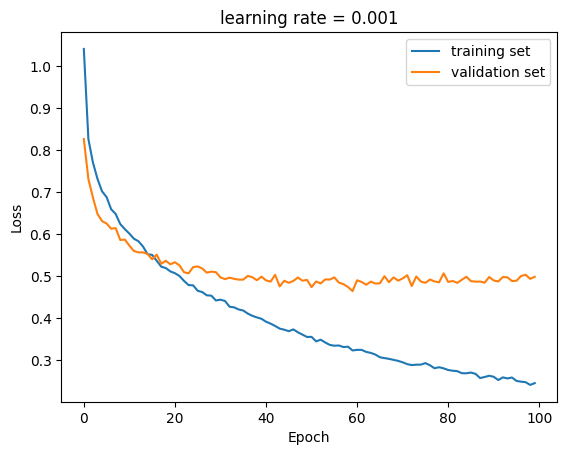

In [16]:
plt.plot(AlexNet1_train_losses, label='training set')
plt.plot(AlexNet1_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

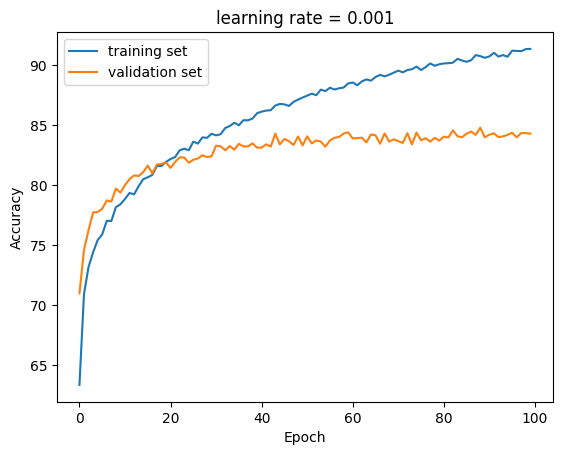

In [17]:
plt.plot(AlexNet1_train_corrects, label='training set')
plt.plot(AlexNet1_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

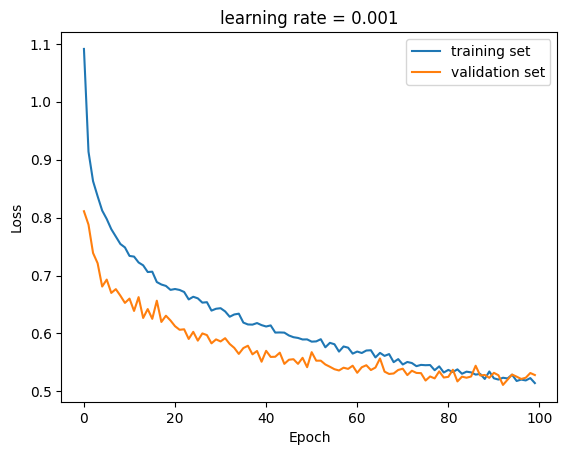

In [18]:
plt.plot(AlexNet2_train_losses, label='training set')
plt.plot(AlexNet2_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

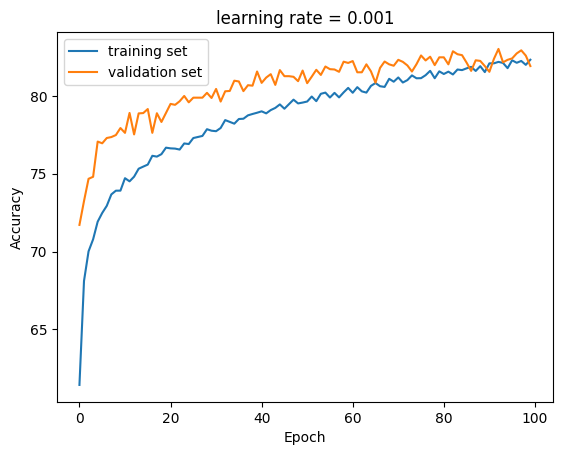

In [19]:
plt.plot(AlexNet2_train_corrects, label='training set')
plt.plot(AlexNet2_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

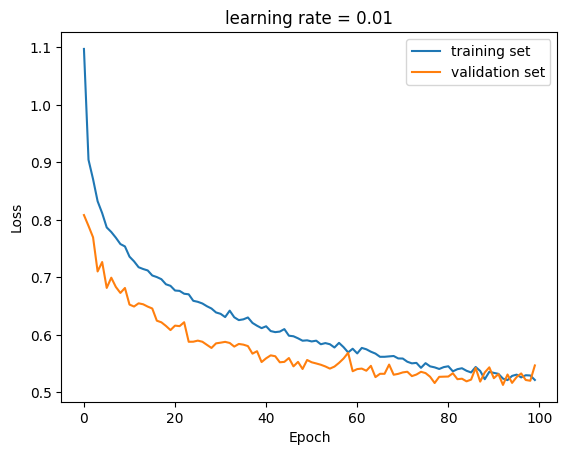

In [20]:
plt.plot(AlexNet3_train_losses, label='training set')
plt.plot(AlexNet3_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.01')
plt.legend()

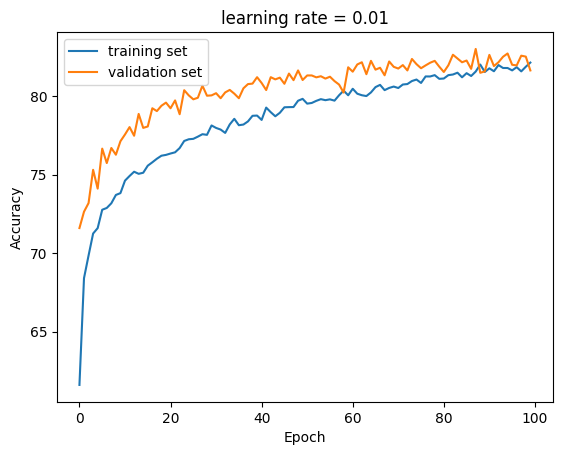

In [21]:
plt.plot(AlexNet3_train_corrects, label='training set')
plt.plot(AlexNet3_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

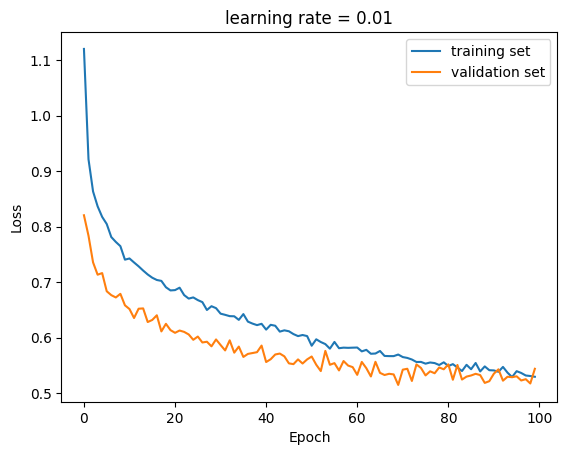

In [22]:
plt.plot(AlexNet4_train_losses, label='training set')
plt.plot(AlexNet4_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.01')
plt.legend()

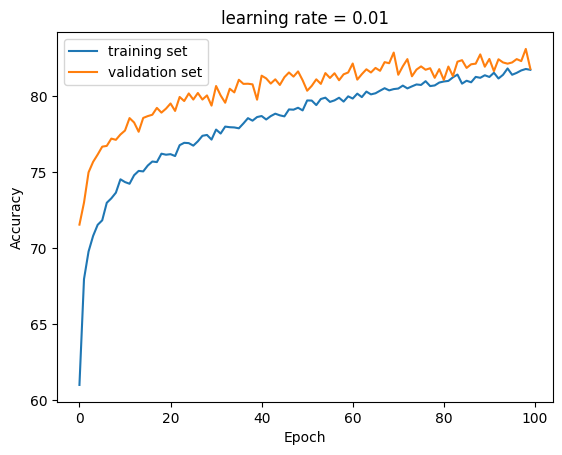

In [23]:
plt.plot(AlexNet4_train_corrects, label='training set')
plt.plot(AlexNet4_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

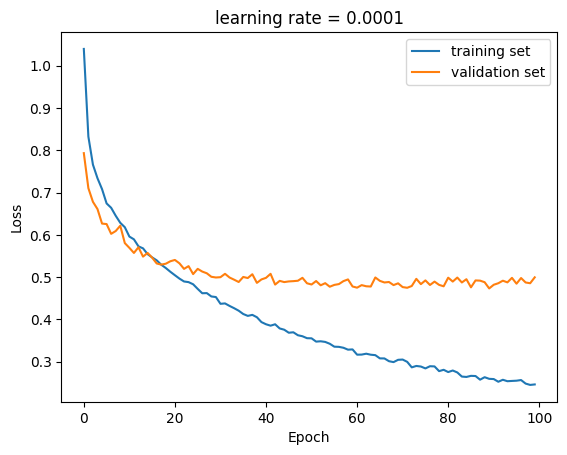

In [24]:
plt.plot(AlexNet5_train_losses, label='training set')
plt.plot(AlexNet5_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

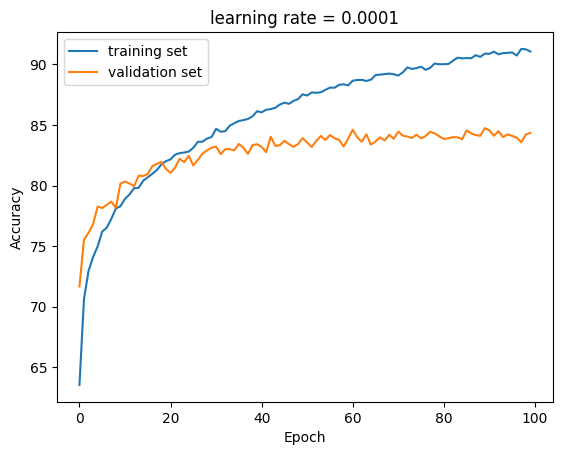

In [25]:
plt.plot(AlexNet5_train_corrects, label='training set')
plt.plot(AlexNet5_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

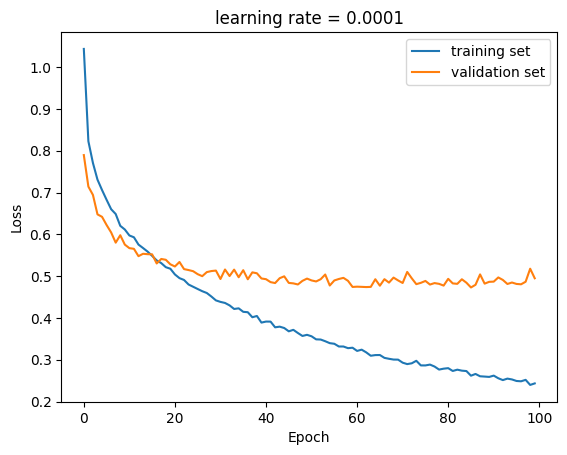

In [26]:
plt.plot(AlexNet6_train_losses, label='training set')
plt.plot(AlexNet6_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

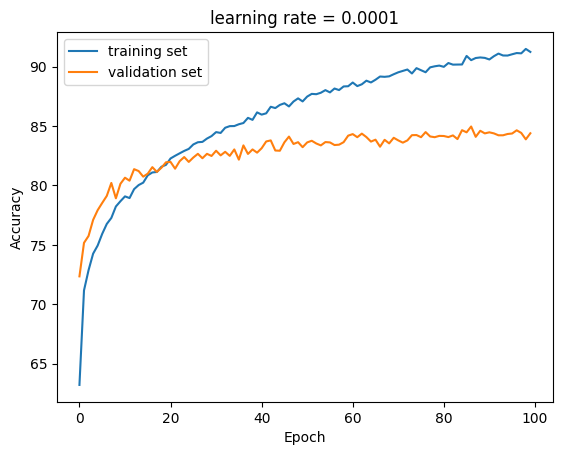

In [27]:
plt.plot(AlexNet6_train_corrects, label='training set')
plt.plot(AlexNet6_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

### test acc

In [28]:
print(evaluate(AlexNet1, Alex_test_loader))
print(evaluate(AlexNet2, Alex_test_loader))
print(evaluate(AlexNet3, Alex_test_loader))
print(evaluate(AlexNet4, Alex_test_loader))
print(evaluate(AlexNet5, Alex_test_loader))
print(evaluate(AlexNet6, Alex_test_loader))

86.96
85.63
85.26
84.95
87.58
87.23


## VGG11

In [50]:
from torchvision.models import vgg11,VGG11_Weights

In [51]:
vgg11_inChannels = 224
vgg11_train_transforms, vgg11_test_transforms = transform(vgg11_inChannels)
vgg11_train_loader, vgg11_val_loader, vgg11_test_loader = load_CIFAR10(vgg11_train_transforms, vgg11_test_transforms)

Files already downloaded and verified
Files already downloaded and verified


### lr=0.001, epoch=100

In [51]:
lr = 0.001
epoch = 10
vgg11Net1 = vgg11(weights = VGG11_Weights.IMAGENET1K_V1)
vgg11Net1.classifier[4] = nn.Linear(4096,1024)
vgg11Net1.classifier[6] = nn.Linear(1024,10)
vgg11Net1.to('cuda')
vgg11Net1_optim = Adam(vgg11Net1.classifier.parameters(), lr=lr)
vgg11Net1_train_losses,vgg11Net1_val_losses,vgg11Net1_train_corrects,vgg11Net1_val_corrects = train(vgg11Net1,vgg11Net1_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 1.5613639858365058, accuracy 55.5675 
validation loss: 0.78914191365242, validation accuracy 73.35 
epoch 2:
training loss: 0.9764556384086609, accuracy 66.475 
validation loss: 0.7301711899042129, validation accuracy 75.97 
epoch 3:
training loss: 0.9018778704106808, accuracy 69.53 
validation loss: 0.6735636827349663, validation accuracy 78.69 
epoch 4:
training loss: 0.8716637615859508, accuracy 70.4525 
validation loss: 0.6491199246048928, validation accuracy 78.59 
epoch 5:
training loss: 0.834388489201665, accuracy 72.16 
validation loss: 0.6399146467447281, validation accuracy 79.99 
epoch 6:
training loss: 0.8167714186012744, accuracy 73.3425 
validation loss: 0.690315754711628, validation accuracy 78.3 
epoch 7:
training loss: 0.8078832995146513, accuracy 73.6825 
validation loss: 0.6701265507936478, validation accuracy 78.8 
epoch 8:
training loss: 0.8080284994095563, accuracy 74.1225 
validation loss: 0.6259819915890694, validation accuracy 79.93 
epo

### lr=0.001, epoch=100

In [65]:
lr = 0.001
epoch = 10
vgg11Net2 = vgg11(weights = VGG11_Weights.IMAGENET1K_V1).to('cuda')
vgg11Net2.classifier[4] = nn.Linear(4096,1024)
vgg11Net2.classifier[6] = nn.Linear(1024,10)
vgg11Net2.to('cuda')
vgg11Net2_optim = Adam(vgg11Net2.classifier.parameters(), lr=lr)
vgg11Net2_train_losses,vgg11Net2_val_losses,vgg11Net2_train_corrects,vgg11Net2_val_corrects = train(vgg11Net2,vgg11Net2_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 1.532789999395609, accuracy 57.605 
validation loss: 0.7546310347318649, validation accuracy 74.88 
epoch 2:
training loss: 0.9343925102055073, accuracy 68.4875 
validation loss: 0.6705469009280205, validation accuracy 77.82 
epoch 3:
training loss: 0.8562023591995239, accuracy 71.8 
validation loss: 0.6927276262640953, validation accuracy 78.57 
epoch 4:
training loss: 0.8426132962107659, accuracy 72.6525 
validation loss: 0.6524396723508835, validation accuracy 78.72 
epoch 5:
training loss: 0.8137449307739735, accuracy 73.595 
validation loss: 0.6375324401259422, validation accuracy 79.61 
epoch 6:
training loss: 0.7905225583910942, accuracy 74.36 
validation loss: 0.6211439019441605, validation accuracy 80.17 
epoch 7:
training loss: 0.7805941044539213, accuracy 74.7225 
validation loss: 0.6876008522510528, validation accuracy 77.87 
epoch 8:
training loss: 0.7747298141568899, accuracy 75.08 
validation loss: 0.6345537960529327, validation accuracy 80.1 
epo

### lr=0.01, epoch=100

In [47]:
lr = 0.001
epoch = 10
vgg11Net3 = vgg11(weights = VGG11_Weights.IMAGENET1K_V1)
vgg11Net3.classifier[4] = nn.Linear(4096,1024)
vgg11Net3.classifier[6] = nn.Linear(1024,10)
vgg11Net3.to('cuda')
vgg11Net3_optim = Adam(vgg11Net3.classifier.parameters(), lr=lr)
vgg11Net3_train_losses,vgg11Net3_val_losses,vgg11Net3_train_corrects,vgg11Net3_val_corrects = train(vgg11Net3,vgg11Net3_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 1.7144313167035579, accuracy 56.4975 
validation loss: 0.7565725511312484, validation accuracy 74.66 
epoch 2:
training loss: 0.9586746881902218, accuracy 67.8775 
validation loss: 0.6612117499113083, validation accuracy 78.24 
epoch 3:
training loss: 0.8704343461990356, accuracy 71.3625 
validation loss: 0.6779899334907532, validation accuracy 77.79 
epoch 4:
training loss: 0.8400847187638283, accuracy 72.515 
validation loss: 0.6666273242235183, validation accuracy 77.93 
epoch 5:
training loss: 0.8034993106126785, accuracy 73.68 
validation loss: 0.6419395190477372, validation accuracy 79.51 
epoch 6:
training loss: 0.7903753363341093, accuracy 74.315 
validation loss: 0.6309516564011574, validation accuracy 79.55 
epoch 7:
training loss: 0.7840661105513572, accuracy 74.4175 
validation loss: 0.639531388580799, validation accuracy 79.55 
epoch 8:
training loss: 0.7545466750860215, accuracy 75.6175 
validation loss: 0.613572812974453, validation accuracy 80.7 

### lr=0.01, epoch=100

In [48]:
lr = 0.001
epoch = 10
vgg11Net4 = vgg11(weights = VGG11_Weights.IMAGENET1K_V1).to('cuda')
vgg11Net4.classifier[4] = nn.Linear(4096,1024)
vgg11Net4.classifier[6] = nn.Linear(1024,10)
vgg11Net4.to('cuda')
vgg11Net4_optim = Adam(vgg11Net4.classifier.parameters(), lr=lr)
vgg11Net4_train_losses,vgg11Net4_val_losses,vgg11Net4_train_corrects,vgg11Net4_val_corrects = train(vgg11Net4,vgg11Net4_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 1.5330886913836002, accuracy 58.425 
validation loss: 0.7627035313844681, validation accuracy 73.51 
epoch 2:
training loss: 0.908886332809925, accuracy 69.4975 
validation loss: 0.7141921323537826, validation accuracy 76.55 
epoch 3:
training loss: 0.8590459924936295, accuracy 72.18 
validation loss: 0.6936910736560822, validation accuracy 77.64 
epoch 4:
training loss: 0.8260171459615231, accuracy 73.2975 
validation loss: 0.7054763868451118, validation accuracy 77.48 
epoch 5:
training loss: 0.8082587964832783, accuracy 74.27 
validation loss: 0.6845923385024071, validation accuracy 78.42 
epoch 6:
training loss: 0.7867558455467224, accuracy 75.1625 
validation loss: 0.656240611076355, validation accuracy 79.36 
epoch 7:
training loss: 0.7717821940779686, accuracy 75.6325 
validation loss: 0.6454908889532089, validation accuracy 80.03 
epoch 8:
training loss: 0.7514222502708435, accuracy 76.2775 
validation loss: 0.6483418953418731, validation accuracy 80.08 

### lr=0.0001, epoch=100

In [49]:
lr = 0.001
epoch = 10
vgg11Net5 = vgg11(weights = VGG11_Weights.IMAGENET1K_V1)
vgg11Net5.classifier[4] = nn.Linear(4096,1024)
vgg11Net5.classifier[6] = nn.Linear(1024,10)
vgg11Net5.to('cuda')
vgg11Net5_optim = Adam(vgg11Net5.classifier.parameters(), lr=lr)
vgg11Net5_train_losses,vgg11Net5_val_losses,vgg11Net5_train_corrects,vgg11Net5_val_corrects = train(vgg11Net5,vgg11Net5_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 1.5185179124772548, accuracy 56.96 
validation loss: 0.7287442898750305, validation accuracy 75.24 
epoch 2:
training loss: 0.9508389607071877, accuracy 68.325 
validation loss: 0.7020146545767784, validation accuracy 77.23 
epoch 3:
training loss: 0.8720368395745755, accuracy 71.395 
validation loss: 0.6633696049451828, validation accuracy 78.14 
epoch 4:
training loss: 0.8373164265602827, accuracy 72.8225 
validation loss: 0.6261646807193756, validation accuracy 79.63 
epoch 5:
training loss: 0.8060225416719914, accuracy 73.565 
validation loss: 0.6544685733318328, validation accuracy 79.22 
epoch 6:
training loss: 0.7836182390898466, accuracy 74.95 
validation loss: 0.6768895563483238, validation accuracy 78.85 
epoch 7:
training loss: 0.7852955189347267, accuracy 74.785 
validation loss: 0.6521607887744904, validation accuracy 80.02 
epoch 8:
training loss: 0.785722148194909, accuracy 75.1475 
validation loss: 0.6453151470422744, validation accuracy 79.58 
e

### lr=0.0001, epoch=100

In [52]:
lr = 0.001
epoch = 10
vgg11Net6 = vgg11(weights = VGG11_Weights.IMAGENET1K_V1)
vgg11Net6.classifier[4] = nn.Linear(4096,1024)
vgg11Net6.classifier[6] = nn.Linear(1024,10)
vgg11Net6.to('cuda')
vgg11Net6_optim = Adam(vgg11Net6.classifier.parameters(), lr=lr)
vgg11Net6_train_losses,vgg11Net6_val_losses,vgg11Net6_train_corrects,vgg11Net6_val_corrects = train(vgg11Net6,vgg11Net6_optim,epoch,vgg11_train_loader,vgg11_val_loader)

Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth
100%|██████████| 507M/507M [00:05<00:00, 91.0MB/s]


epoch 1:
training loss: 1.4959478570520879, accuracy 57.7225 
validation loss: 0.7984988671541214, validation accuracy 72.31 
epoch 2:
training loss: 0.957544339299202, accuracy 68.25 
validation loss: 0.6694761869311333, validation accuracy 78.15 
epoch 3:
training loss: 0.8669583724439144, accuracy 71.615 
validation loss: 0.6799951735138893, validation accuracy 77.34 
epoch 4:
training loss: 0.8434918722510338, accuracy 72.585 
validation loss: 0.6596093720197678, validation accuracy 79.12 
epoch 5:
training loss: 0.8224196340888739, accuracy 73.4925 
validation loss: 0.6830586513876915, validation accuracy 78.37 
epoch 6:
training loss: 0.8003907356411218, accuracy 74.485 
validation loss: 0.6629051104187965, validation accuracy 78.29 
epoch 7:
training loss: 0.7879872290045022, accuracy 75.0225 
validation loss: 0.6624326422810555, validation accuracy 79.36 
epoch 8:
training loss: 0.7973716273903847, accuracy 75.1025 
validation loss: 0.6756496423482895, validation accuracy 78.49

### loss/acc graph

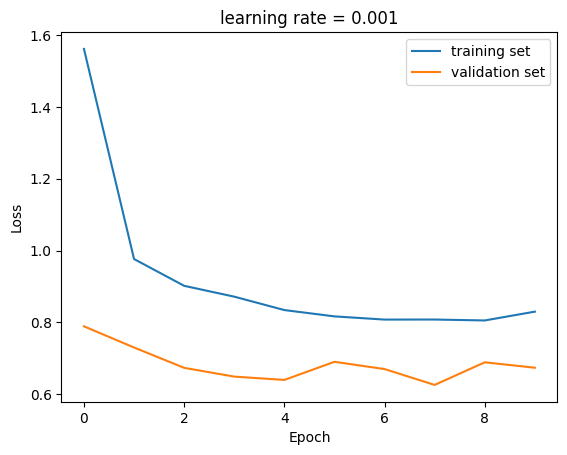

In [66]:
plt.plot(vgg11Net1_train_losses, label='training set')
plt.plot(vgg11Net1_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

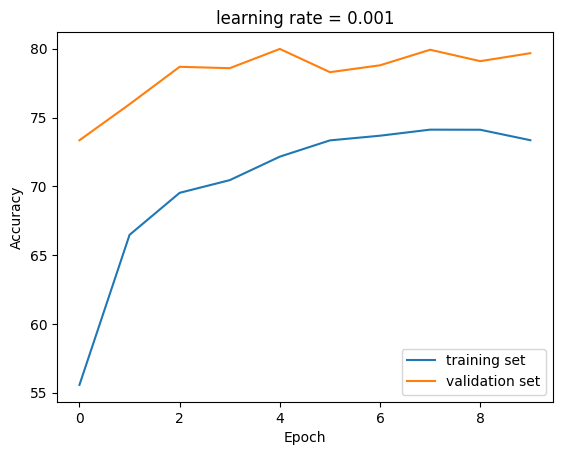

In [67]:
plt.plot(vgg11Net1_train_corrects, label='training set')
plt.plot(vgg11Net1_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

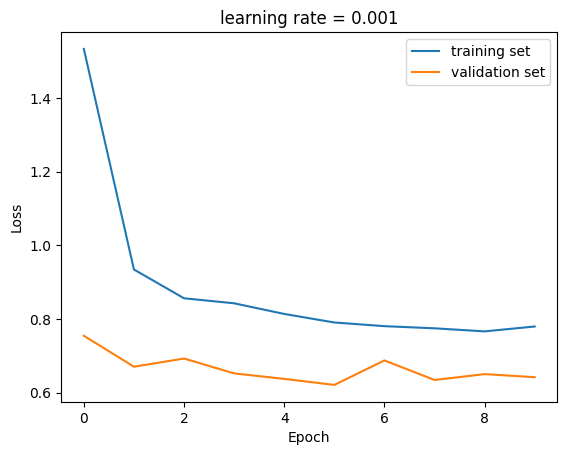

In [68]:
plt.plot(vgg11Net2_train_losses, label='training set')
plt.plot(vgg11Net2_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

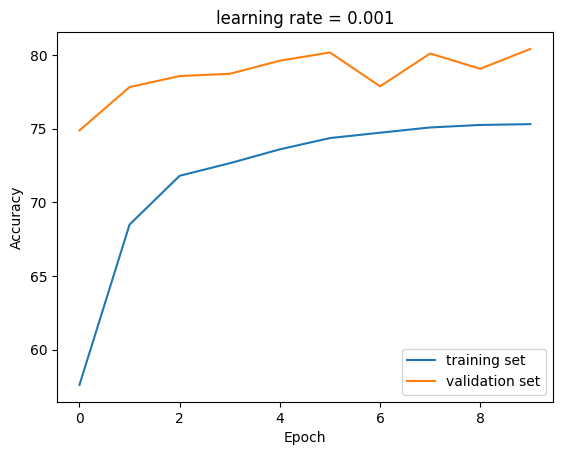

In [69]:
plt.plot(vgg11Net2_train_corrects, label='training set')
plt.plot(vgg11Net2_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

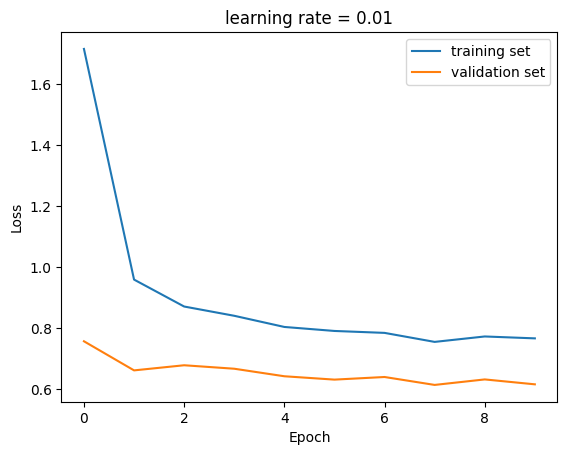

In [70]:
plt.plot(vgg11Net3_train_losses, label='training set')
plt.plot(vgg11Net3_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.01')
plt.legend()

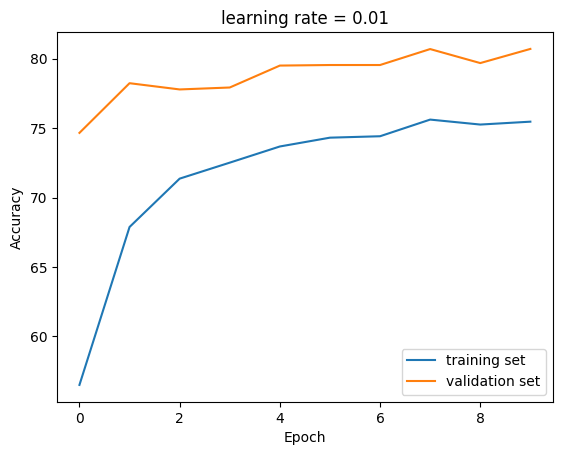

In [71]:
plt.plot(vgg11Net3_train_corrects, label='training set')
plt.plot(vgg11Net3_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

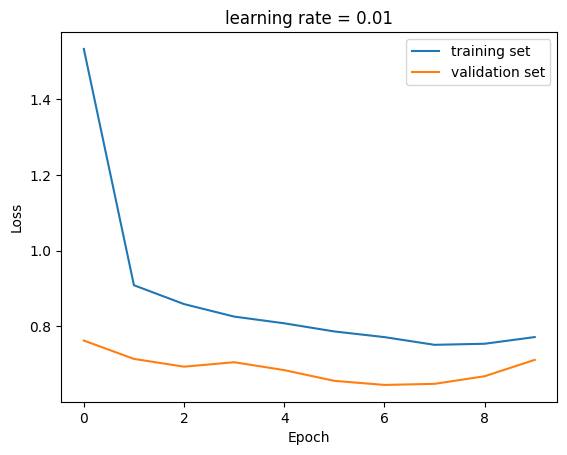

In [72]:
plt.plot(vgg11Net4_train_losses, label='training set')
plt.plot(vgg11Net4_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.01')
plt.legend()

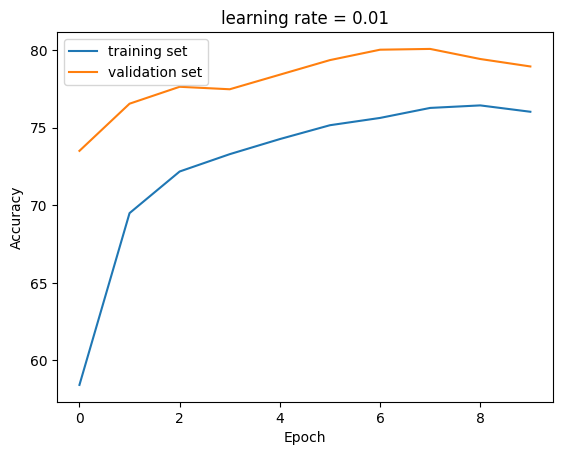

In [73]:
plt.plot(vgg11Net4_train_corrects, label='training set')
plt.plot(vgg11Net4_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

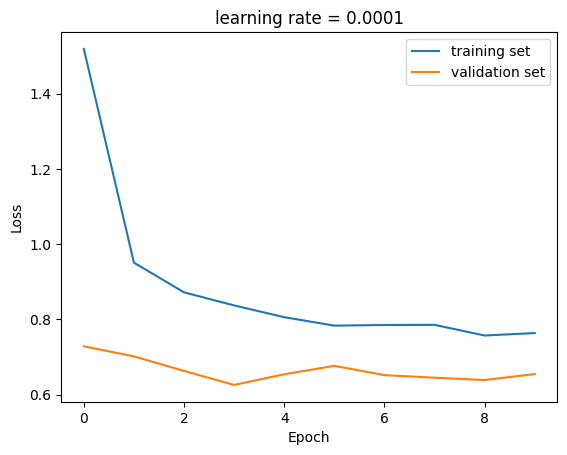

In [74]:
plt.plot(vgg11Net5_train_losses, label='training set')
plt.plot(vgg11Net5_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

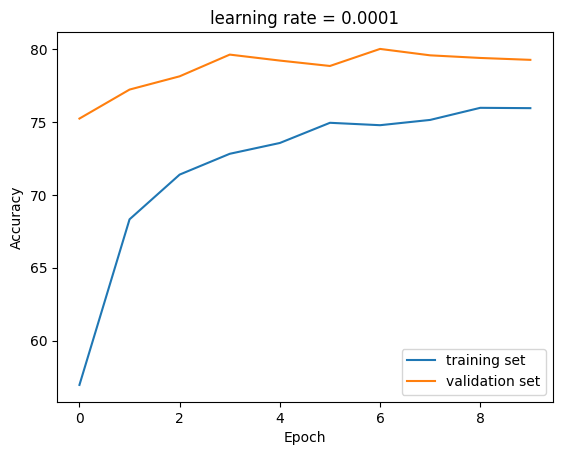

In [75]:
plt.plot(vgg11Net5_train_corrects, label='training set')
plt.plot(vgg11Net5_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

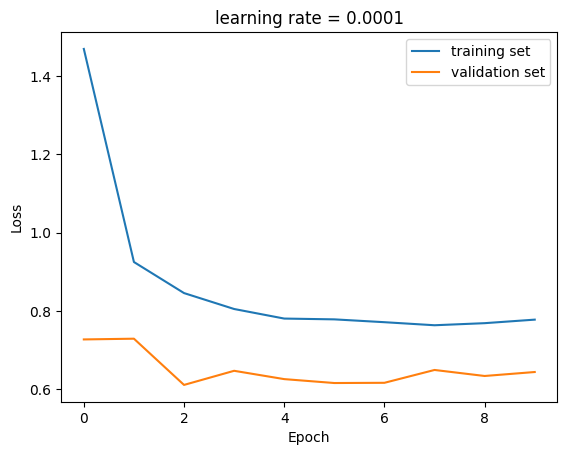

In [76]:
plt.plot(vgg11Net6_train_losses, label='training set')
plt.plot(vgg11Net6_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

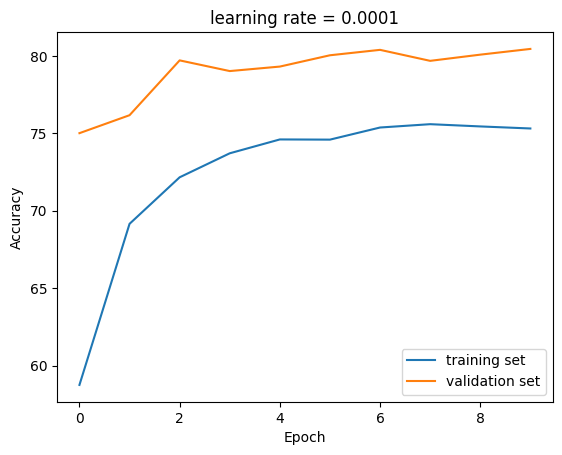

In [77]:
plt.plot(vgg11Net6_train_corrects, label='training set')
plt.plot(vgg11Net6_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

### test acc

In [78]:
print(evaluate(vgg11Net1, vgg11_test_loader))
print(evaluate(vgg11Net2, vgg11_test_loader))
print(evaluate(vgg11Net3, vgg11_test_loader))
print(evaluate(vgg11Net4, vgg11_test_loader))
print(evaluate(vgg11Net5, vgg11_test_loader))
print(evaluate(vgg11Net6, vgg11_test_loader))

82.89
84.04
84.17
83.06
84.04
83.56


## ResNet

In [15]:
from torchvision.models import resnet18,ResNet18_Weights

In [16]:
Res_inChannels = 32
Res_train_transforms, Res_test_transforms = transform(Res_inChannels)
Res_train_loader, Res_val_loader, Res_test_loader = load_CIFAR10(Res_train_transforms, Res_test_transforms)

Files already downloaded and verified
Files already downloaded and verified


### lr=0.001, epoch=100

In [17]:
lr = 0.0001
epoch = 50
ResNet1 = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1)
ResNet1.fc = nn.Linear(512,10)
ResNet1.to('cuda')
ResNet1_optim = Adam(ResNet1.parameters(), lr=lr)
ResNet1_train_losses,ResNet1_val_losses,ResNet1_train_corrects,ResNet1_val_corrects = train(ResNet1,ResNet1_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 1.2197009037435054, accuracy 57.4775 
validation loss: 0.8680449348688125, validation accuracy 70.34 
epoch 2:
training loss: 0.7836166022717953, accuracy 72.6775 
validation loss: 0.7311801517009735, validation accuracy 75.23 
epoch 3:
training loss: 0.6523105619102716, accuracy 77.3325 
validation loss: 0.6780189329385757, validation accuracy 77.08 
epoch 4:
training loss: 0.5743621473759413, accuracy 79.8325 
validation loss: 0.6181350257992745, validation accuracy 78.86 
epoch 5:
training loss: 0.51155163384974, accuracy 82.0125 
validation loss: 0.6060359364748001, validation accuracy 79.93 
epoch 6:
training loss: 0.4609312100708485, accuracy 83.9725 
validation loss: 0.5883032137155533, validation accuracy 80.44 
epoch 7:
training loss: 0.41293548986315726, accuracy 85.3825 
validation loss: 0.5903879082202912, validation accuracy 80.31 
epoch 8:
training loss: 0.3781461789086461, accuracy 86.8125 
validation loss: 0.5970987856388092, validation accuracy 

### lr=0.001, epoch=100

In [18]:
lr = 0.0001
epoch = 50
ResNet2 = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1).to('cuda')
ResNet2.fc = nn.Linear(512,10)
ResNet2.to('cuda')
ResNet2_optim = Adam(ResNet2.parameters(), lr=lr)
ResNet2_train_losses,ResNet2_val_losses,ResNet2_train_corrects,ResNet2_val_corrects = train(ResNet2,ResNet2_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 1.2263544669747353, accuracy 56.89 
validation loss: 0.8646920889616012, validation accuracy 70.48 
epoch 2:
training loss: 0.7786724182218313, accuracy 72.8925 
validation loss: 0.723946151137352, validation accuracy 74.91 
epoch 3:
training loss: 0.6552829696983099, accuracy 77.285 
validation loss: 0.6575242054462432, validation accuracy 77.27 
epoch 4:
training loss: 0.5712246733903885, accuracy 80.16 
validation loss: 0.6322758117318154, validation accuracy 78.6 
epoch 5:
training loss: 0.505574446246028, accuracy 82.41 
validation loss: 0.5939341798424721, validation accuracy 80.01 
epoch 6:
training loss: 0.4561536201834679, accuracy 83.915 
validation loss: 0.5951804301142692, validation accuracy 80.02 
epoch 7:
training loss: 0.4155915141478181, accuracy 85.3375 
validation loss: 0.5965862423181534, validation accuracy 80.55 
epoch 8:
training loss: 0.3778066677227616, accuracy 86.7275 
validation loss: 0.5831370934844017, validation accuracy 81.1 
epoc

### lr=0.01, epoch=100

In [19]:
lr = 0.0001
epoch = 50
ResNet3 = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1)
ResNet3.fc = nn.Linear(512,10)
ResNet3.to('cuda')
ResNet3_optim = Adam(ResNet3.parameters(), lr=lr)
ResNet3_train_losses,ResNet3_val_losses,ResNet3_train_corrects,ResNet3_val_corrects = train(ResNet3,ResNet3_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 1.2206752851605416, accuracy 57.185 
validation loss: 0.8671091985702515, validation accuracy 69.82 
epoch 2:
training loss: 0.7846234375983476, accuracy 72.635 
validation loss: 0.7164214789867401, validation accuracy 75.39 
epoch 3:
training loss: 0.6577984251827002, accuracy 77.1925 
validation loss: 0.6531659060716629, validation accuracy 77.74 
epoch 4:
training loss: 0.5689307716488838, accuracy 80.3775 
validation loss: 0.6248277017474174, validation accuracy 79.32 
epoch 5:
training loss: 0.5093301745504141, accuracy 82.1625 
validation loss: 0.6029438665509224, validation accuracy 79.5 
epoch 6:
training loss: 0.45475812166929247, accuracy 84.015 
validation loss: 0.5973838672041893, validation accuracy 80.29 
epoch 7:
training loss: 0.4169683440029621, accuracy 85.38 
validation loss: 0.5687006443738938, validation accuracy 80.83 
epoch 8:
training loss: 0.37628584798425435, accuracy 86.7525 
validation loss: 0.5852483373880386, validation accuracy 80.

### lr=0.01, epoch=100

In [20]:
lr = 0.0001
epoch = 50
ResNet4 = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1)
ResNet4.fc = nn.Linear(512,10)
ResNet4.to('cuda')
ResNet4_optim = Adam(ResNet4.parameters(), lr=lr)
ResNet4_train_losses,ResNet4_val_losses,ResNet4_train_corrects,ResNet4_val_corrects = train(ResNet4,ResNet4_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 1.2274028791487217, accuracy 57.0975 
validation loss: 0.8864630419015884, validation accuracy 69.53 
epoch 2:
training loss: 0.7893708089739084, accuracy 72.7825 
validation loss: 0.7161180087924004, validation accuracy 75.23 
epoch 3:
training loss: 0.658771683499217, accuracy 77.1725 
validation loss: 0.6736614438891411, validation accuracy 76.65 
epoch 4:
training loss: 0.5704683291167021, accuracy 80.0 
validation loss: 0.6346540462970733, validation accuracy 78.91 
epoch 5:
training loss: 0.5112399974837899, accuracy 82.12 
validation loss: 0.6037657344341278, validation accuracy 79.37 
epoch 6:
training loss: 0.45880306374281643, accuracy 83.9175 
validation loss: 0.5886952394247055, validation accuracy 80.17 
epoch 7:
training loss: 0.4152845257520676, accuracy 85.395 
validation loss: 0.587136752307415, validation accuracy 80.39 
epoch 8:
training loss: 0.3721983499079943, accuracy 87.04 
validation loss: 0.576673643887043, validation accuracy 81.4 
epo

### lr=0.0001, epoch=100

In [21]:
lr = 0.0001
epoch = 50
ResNet5 = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1)
ResNet5.fc = nn.Linear(512,10)
ResNet5.to('cuda')
ResNet5_optim = Adam(ResNet5.parameters(), lr=lr)
ResNet5_train_losses,ResNet5_val_losses,ResNet5_train_corrects,ResNet5_val_corrects = train(ResNet5,ResNet5_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 1.235000329911709, accuracy 56.8525 
validation loss: 0.8572382837533951, validation accuracy 70.93 
epoch 2:
training loss: 0.7853924696147442, accuracy 72.6625 
validation loss: 0.735782595872879, validation accuracy 74.81 
epoch 3:
training loss: 0.6599389317631722, accuracy 77.205 
validation loss: 0.655839170217514, validation accuracy 77.65 
epoch 4:
training loss: 0.5716403263062239, accuracy 79.9575 
validation loss: 0.636178312599659, validation accuracy 78.64 
epoch 5:
training loss: 0.5133674440532923, accuracy 82.1025 
validation loss: 0.6131252357363701, validation accuracy 79.58 
epoch 6:
training loss: 0.46059366919100286, accuracy 83.9925 
validation loss: 0.6082177138328553, validation accuracy 79.66 
epoch 7:
training loss: 0.4121431160345674, accuracy 85.5175 
validation loss: 0.5936790519952774, validation accuracy 80.4 
epoch 8:
training loss: 0.3722325173392892, accuracy 86.985 
validation loss: 0.5918400913476944, validation accuracy 80.4 

### lr=0.0001, epoch=100

In [22]:
lr = 0.0001
epoch = 50
ResNet6 = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1)
ResNet6.fc = nn.Linear(512,10)
ResNet6.to('cuda')
ResNet6_optim = Adam(ResNet6.parameters(), lr=lr)
ResNet6_train_losses,ResNet6_val_losses,ResNet6_train_corrects,ResNet6_val_corrects = train(ResNet6,ResNet6_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 1.2155844016373158, accuracy 57.5175 
validation loss: 0.8553238689899445, validation accuracy 70.39 
epoch 2:
training loss: 0.7904092347621918, accuracy 72.705 
validation loss: 0.7150468334555626, validation accuracy 75.53 
epoch 3:
training loss: 0.6546514469385147, accuracy 77.17 
validation loss: 0.6592856058478356, validation accuracy 77.61 
epoch 4:
training loss: 0.5744534364342689, accuracy 80.05 
validation loss: 0.6351311004161835, validation accuracy 78.23 
epoch 5:
training loss: 0.5107021792978048, accuracy 82.045 
validation loss: 0.608636064529419, validation accuracy 79.27 
epoch 6:
training loss: 0.46209483794867995, accuracy 83.62 
validation loss: 0.603965027332306, validation accuracy 79.75 
epoch 7:
training loss: 0.41920922603458166, accuracy 85.305 
validation loss: 0.5776223948597908, validation accuracy 80.67 
epoch 8:
training loss: 0.3796299779042602, accuracy 86.5775 
validation loss: 0.5825525906682014, validation accuracy 80.64 
e

### loss/acc graph

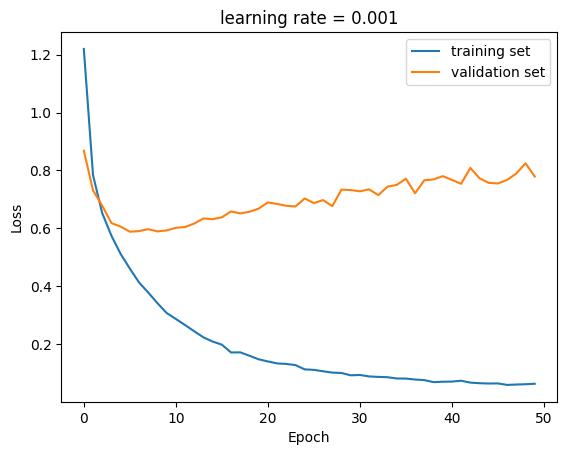

In [23]:
plt.plot(ResNet1_train_losses, label='training set')
plt.plot(ResNet1_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

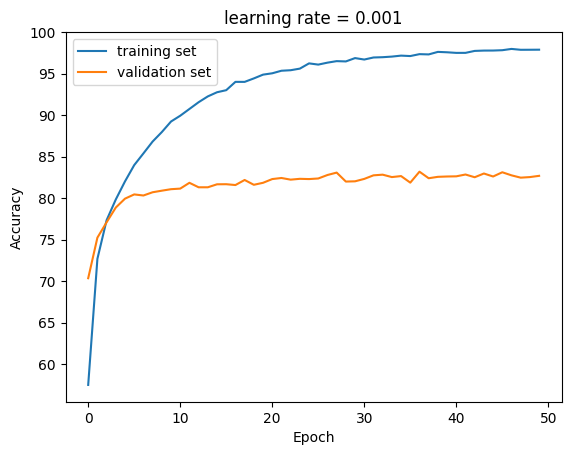

In [24]:
plt.plot(ResNet1_train_corrects, label='training set')
plt.plot(ResNet1_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

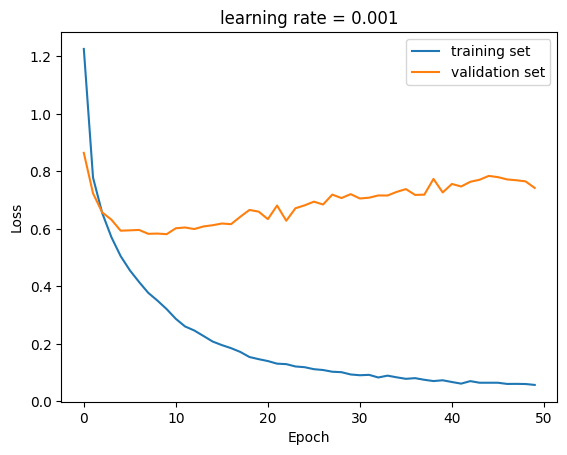

In [25]:
plt.plot(ResNet2_train_losses, label='training set')
plt.plot(ResNet2_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.001')
plt.legend()

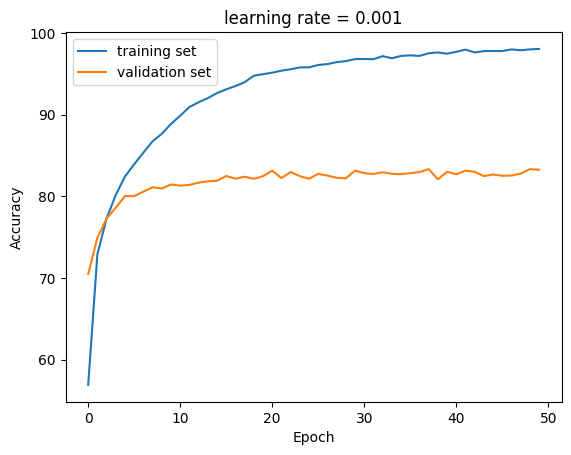

In [26]:
plt.plot(ResNet2_train_corrects, label='training set')
plt.plot(ResNet2_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.001')
plt.legend()

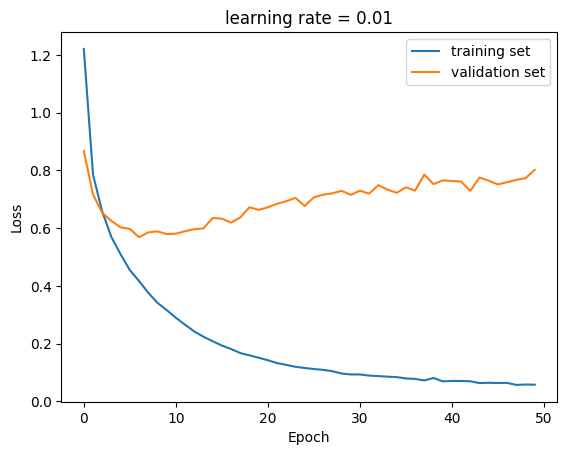

In [27]:
plt.plot(ResNet3_train_losses, label='training set')
plt.plot(ResNet3_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.01')
plt.legend()

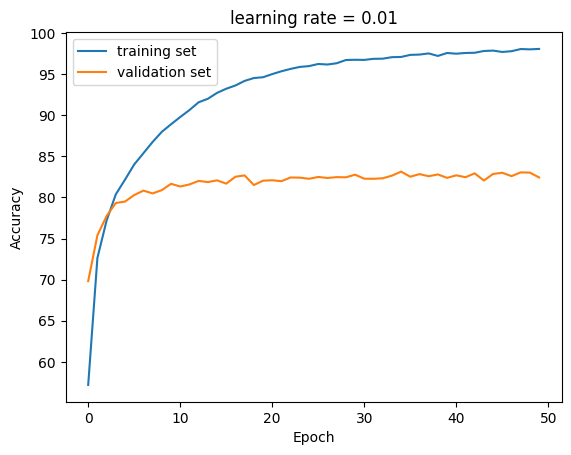

In [28]:
plt.plot(ResNet3_train_corrects, label='training set')
plt.plot(ResNet3_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

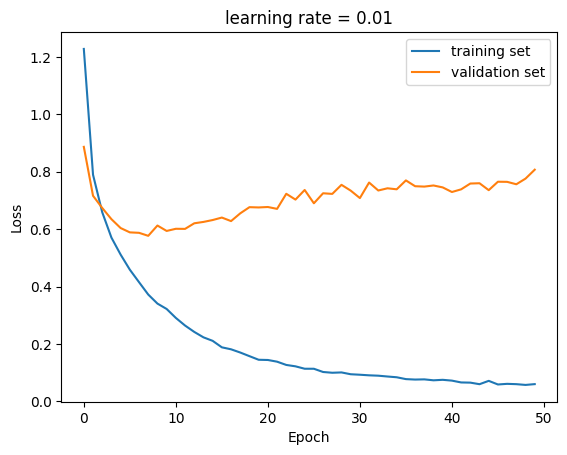

In [29]:
plt.plot(ResNet4_train_losses, label='training set')
plt.plot(ResNet4_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.01')
plt.legend()

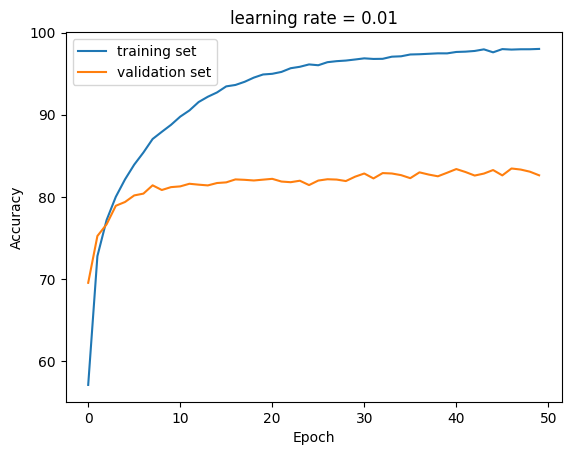

In [30]:
plt.plot(ResNet4_train_corrects, label='training set')
plt.plot(ResNet4_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.01')
plt.legend()

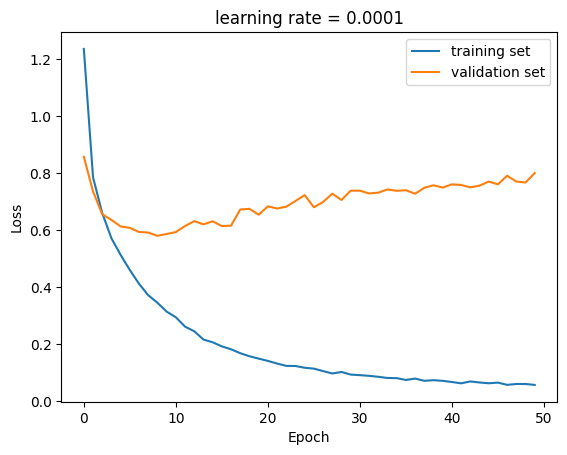

In [31]:
plt.plot(ResNet5_train_losses, label='training set')
plt.plot(ResNet5_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

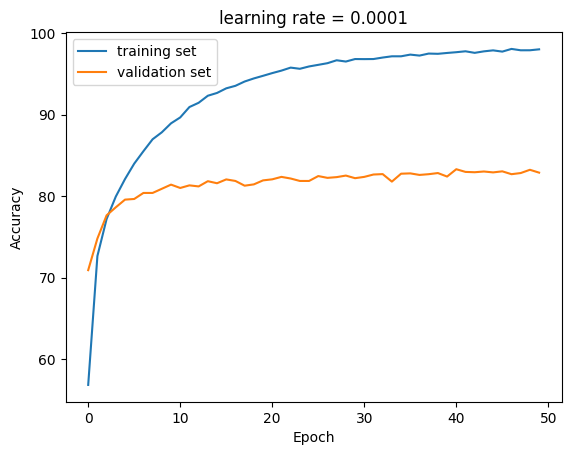

In [32]:
plt.plot(ResNet5_train_corrects, label='training set')
plt.plot(ResNet5_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

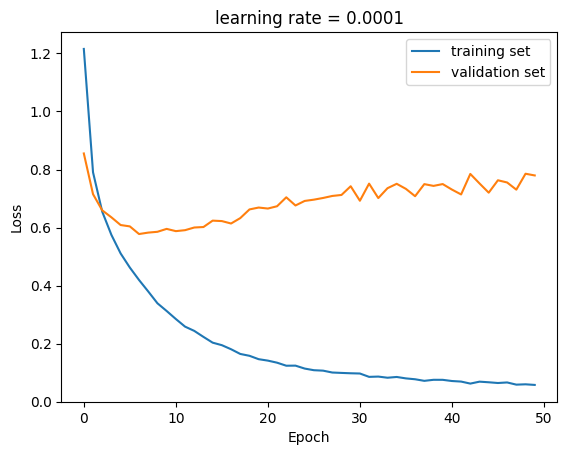

In [33]:
plt.plot(ResNet6_train_losses, label='training set')
plt.plot(ResNet6_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('learning rate = 0.0001')
plt.legend()

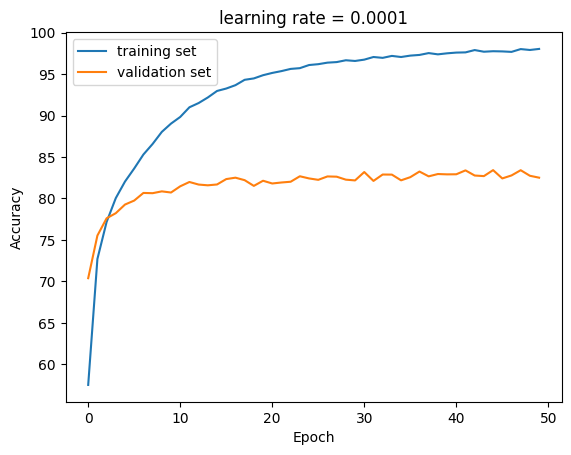

In [34]:
plt.plot(ResNet6_train_corrects, label='training set')
plt.plot(ResNet6_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('learning rate = 0.0001')
plt.legend()

### test acc

In [35]:
print(evaluate(ResNet1, Res_test_loader))
print(evaluate(ResNet2, Res_test_loader))
print(evaluate(ResNet3, Res_test_loader))
print(evaluate(ResNet4, Res_test_loader))
print(evaluate(ResNet5, Res_test_loader))
print(evaluate(ResNet6, Res_test_loader))

83.59
84.1
84.21
83.86
84.29
84.15


# Ensemble stacking

In [38]:
class MetaNet3(nn.Module):   
    def __init__(self, modelA, modelB, modelC):
        super().__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.modelC = modelC
        self.classifier = nn.Linear(10 * 3, 10)
        
    def forward(self, x):
        x1 = self.modelA(x)
        x2 = self.modelB(x)
        x3 = self.modelC(x)
        x = torch.cat((x1, x2, x3), dim=1)
        return self.classifier(x)

In [39]:
class MetaNet6(nn.Module):   
    def __init__(self, modelA, modelB, modelC, modelD, modelE, modelF):
        super().__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.modelC = modelC
        self.modelD = modelD
        self.modelE = modelE
        self.modelF = modelF
        self.classifier = nn.Linear(10 * 6, 10)
        
    def forward(self, x):
        x1 = self.modelA(x)
        x2 = self.modelB(x)
        x3 = self.modelC(x)
        x4 = self.modelD(x)
        x5 = self.modelE(x)
        x6 = self.modelF(x)
        x = torch.cat((x1, x2, x3, x4, x5, x6), dim=1)
        return self.classifier(x)

## LeNet

In [ ]:
epoch = 20
lr = 0.001

network_Le_meta6 = MetaNet6(LeNet1, LeNet2, LeNet3, LeNet4, LeNet5, LeNet6).to('cuda')
for param in network_Le_meta6.parameters():
    param.requires_grad = False
for param in network_Le_meta6.classifier.parameters():
    param.requires_grad = True 
Le_meta6_optim = Adam(network_Le_meta6.parameters(), lr=lr)

Le_meta6_train_losses,Le_meta6_val_losses,Le_meta6_train_corrects,Le_meta6_val_corrects = train(network_Le_meta6,Le_meta6_optim,epoch,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.1364241346716881, accuracy 62.8375 
validation loss: 0.9977095305919648, validation accuracy 67.8 
epoch 2:
training loss: 0.8444580887258053, accuracy 73.3375 
validation loss: 1.0095939993858338, validation accuracy 68.84 
epoch 3:
training loss: 0.820007065013051, accuracy 73.895 
validation loss: 0.9974142563343048, validation accuracy 69.14 
epoch 4:
training loss: 0.8159122593700886, accuracy 74.3575 
validation loss: 0.9958701819181442, validation accuracy 69.03 
epoch 5:
training loss: 0.8045557171106339, accuracy 74.525 
validation loss: 1.00562968313694, validation accuracy 69.14 
epoch 6:
training loss: 0.8017774043232202, accuracy 74.675 
validation loss: 1.0005439549684525, validation accuracy 69.41 
epoch 7:
training loss: 0.797162551060319, accuracy 74.7225 
validation loss: 0.9907109063863754, validation accuracy 69.47 
epoch 8:
training loss: 0.7980092009902, accuracy 74.895 
validation loss: 1.0022483229637147, validation accuracy 68.68 
epoc

In [ ]:
epoch = 20
lr = 0.001

network_Le_meta3 = MetaNet3(LeNet1, LeNet2, LeNet3).to('cuda')
for param in network_Le_meta3.parameters():
    param.requires_grad = False
for param in network_Le_meta3.classifier.parameters():
    param.requires_grad = True 
Le_meta3_optim = Adam(network_Le_meta3.parameters(), lr=lr)

Le_meta3_train_losses,Le_meta3_val_losses,Le_meta3_train_corrects,Le_meta3_val_corrects = train(network_Le_meta3,Le_meta3_optim,epoch,Le_train_loader,Le_val_loader)

epoch 1:
training loss: 1.2350976938009262, accuracy 59.4325 
validation loss: 1.0350921404361726, validation accuracy 66.42 
epoch 2:
training loss: 0.8535128363966942, accuracy 72.945 
validation loss: 0.987955396771431, validation accuracy 68.36 
epoch 3:
training loss: 0.8163757416605949, accuracy 74.0425 
validation loss: 1.0042873901128768, validation accuracy 68.69 
epoch 4:
training loss: 0.8065270383656025, accuracy 74.175 
validation loss: 0.9987514567375183, validation accuracy 69.18 
epoch 5:
training loss: 0.7998405677080155, accuracy 74.72 
validation loss: 1.0100205844640733, validation accuracy 68.74 
epoch 6:
training loss: 0.7928942142426968, accuracy 74.765 
validation loss: 0.9971823042631149, validation accuracy 69.59 
epoch 7:
training loss: 0.7962667293846607, accuracy 74.6775 
validation loss: 1.0101572197675706, validation accuracy 68.85 
epoch 8:
training loss: 0.7959380379319191, accuracy 74.745 
validation loss: 1.0079305851459504, validation accuracy 68.93 

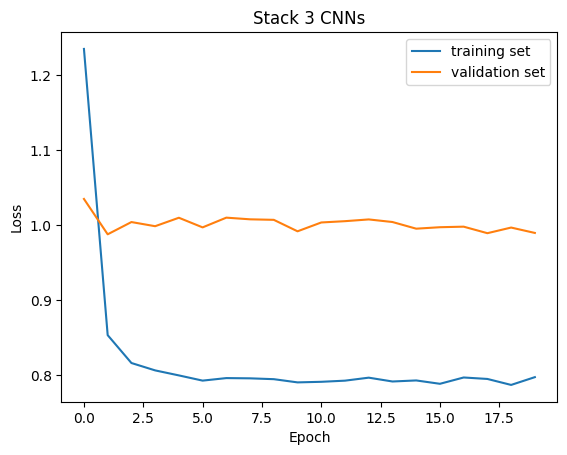

In [ ]:
plt.plot(Le_meta3_train_losses, label='training set')
plt.plot(Le_meta3_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stack 3 CNNs')
plt.legend()

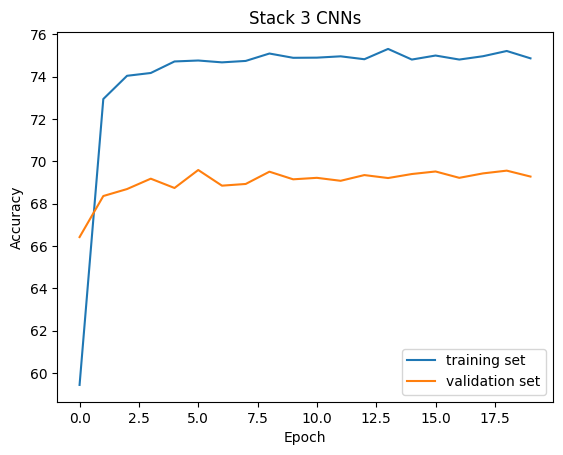

In [ ]:
plt.plot(Le_meta3_train_corrects, label='training set')
plt.plot(Le_meta3_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stack 3 CNNs')
plt.legend()

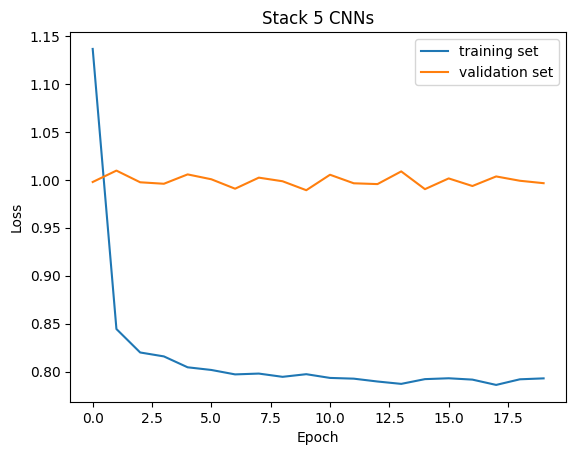

In [ ]:
plt.plot(Le_meta6_train_losses, label='training set')
plt.plot(Le_meta6_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stack 5 CNNs')
plt.legend()

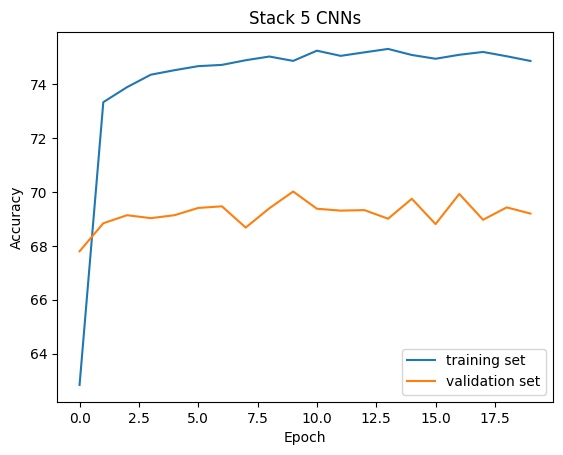

In [ ]:
plt.plot(Le_meta6_train_corrects, label='training set')
plt.plot(Le_meta6_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stack 5 CNNs')
plt.legend()

In [ ]:
print(evaluate(network_Le_meta3, Le_test_loader))
print(evaluate(network_Le_meta6, Le_test_loader))

70.98
70.9


## AlexNet

In [35]:
epoch = 20
lr = 0.001

network_Alex_meta6 = MetaNet6(AlexNet1, AlexNet2, AlexNet3, AlexNet4, AlexNet5, AlexNet6).to('cuda')
for param in network_Alex_meta6.parameters():
    param.requires_grad = False

for param in network_Alex_meta6.classifier.parameters():
    param.requires_grad = True 
Alex_meta6_optim = Adam(network_Alex_meta6.parameters(), lr=lr)
Alex_meta6_train_losses,Alex_meta6_val_losses,Alex_meta6_train_corrects,Alex_meta6_val_corrects = train(network_Alex_meta6,Alex_meta6_optim,epoch,Alex_train_loader,Alex_val_loader)

epoch 1:
training loss: 0.9344842553697527, accuracy 78.285 
validation loss: 0.480232675075531, validation accuracy 84.17 
epoch 2:
training loss: 0.2174171548895538, accuracy 92.9825 
validation loss: 0.4587615865468979, validation accuracy 84.76 
epoch 3:
training loss: 0.17385085286572577, accuracy 94.255 
validation loss: 0.4639701771736145, validation accuracy 85.02 
epoch 4:
training loss: 0.15730933987535536, accuracy 94.6075 
validation loss: 0.4838034641742706, validation accuracy 84.83 
epoch 5:
training loss: 0.15105811374261977, accuracy 94.855 
validation loss: 0.49010799914598463, validation accuracy 85.19 
epoch 6:
training loss: 0.1386501797940582, accuracy 95.1225 
validation loss: 0.49267604649066926, validation accuracy 85.35 
epoch 7:
training loss: 0.13626928356476128, accuracy 95.24 
validation loss: 0.49180739134550094, validation accuracy 85.91 
epoch 8:
training loss: 0.13491302540525793, accuracy 95.195 
validation loss: 0.4937675654888153, validation accurac

In [36]:
epoch = 20
lr = 0.001

network_Alex_meta3 = MetaNet3(AlexNet1, AlexNet5, AlexNet6).to('cuda')
for param in network_Alex_meta3.parameters():
    param.requires_grad = False
for param in network_Alex_meta3.classifier.parameters():
    param.requires_grad = True 
Alex_meta3_optim = Adam(network_Alex_meta3.parameters(), lr=lr)

Alex_meta3_train_losses,Alex_meta3_val_losses,Alex_meta3_train_corrects,Alex_meta3_val_corrects = train(network_Alex_meta3,Alex_meta3_optim,epoch,Alex_train_loader,Alex_val_loader)

epoch 1:
training loss: 1.2222614950686692, accuracy 68.645 
validation loss: 0.5179584309458732, validation accuracy 83.46 
epoch 2:
training loss: 0.245161066185683, accuracy 93.0375 
validation loss: 0.45682547211647034, validation accuracy 84.79 
epoch 3:
training loss: 0.18260602766647935, accuracy 94.5325 
validation loss: 0.45289871364831924, validation accuracy 84.98 
epoch 4:
training loss: 0.15749087280593813, accuracy 94.98 
validation loss: 0.46073830157518386, validation accuracy 85.55 
epoch 5:
training loss: 0.1459235847182572, accuracy 95.3775 
validation loss: 0.46022712528705595, validation accuracy 85.21 
epoch 6:
training loss: 0.1383236267976463, accuracy 95.45 
validation loss: 0.480926119685173, validation accuracy 84.97 
epoch 7:
training loss: 0.12891682809218763, accuracy 95.665 
validation loss: 0.4759962426126003, validation accuracy 85.45 
epoch 8:
training loss: 0.12953844049014152, accuracy 95.55 
validation loss: 0.48728508189320563, validation accuracy 

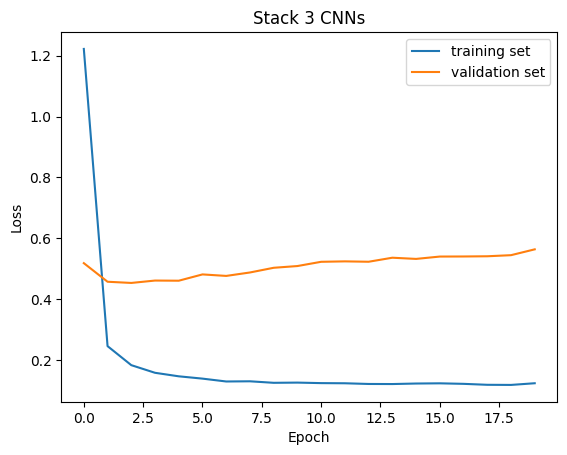

In [37]:
plt.plot(Alex_meta3_train_losses, label='training set')
plt.plot(Alex_meta3_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stack 3 CNNs')
plt.legend()

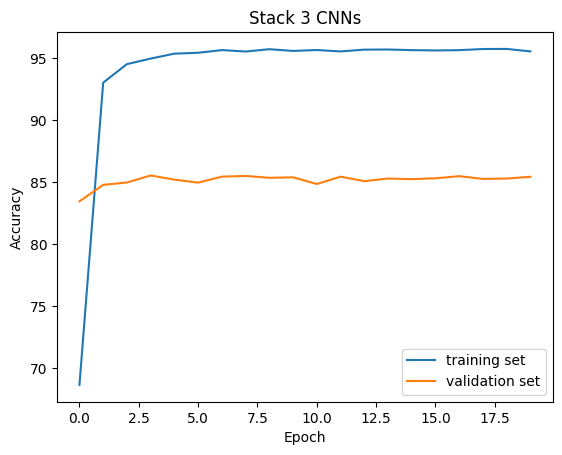

In [38]:
plt.plot(Alex_meta3_train_corrects, label='training set')
plt.plot(Alex_meta3_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stack 3 CNNs')
plt.legend()

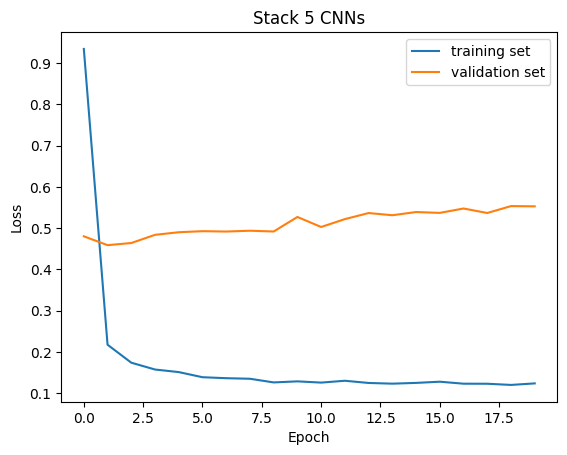

In [39]:
plt.plot(Alex_meta6_train_losses, label='training set')
plt.plot(Alex_meta6_val_losses, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stack 5 CNNs')
plt.legend()

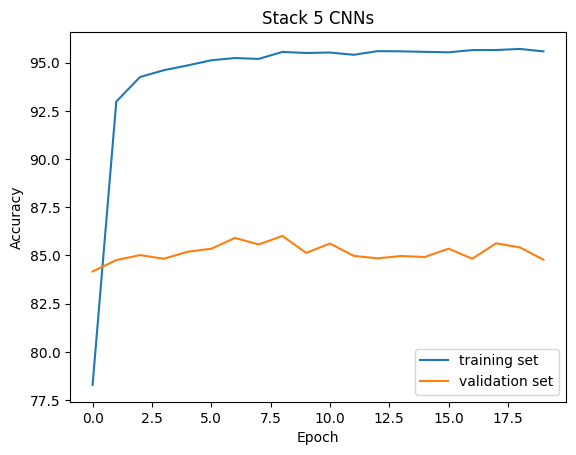

In [40]:
plt.plot(Alex_meta6_train_corrects, label='training set')
plt.plot(Alex_meta6_val_corrects, label='validation set')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stack 5 CNNs')
plt.legend()

In [41]:
print(evaluate(network_Alex_meta3, Alex_test_loader))
print(evaluate(network_Alex_meta6, Alex_test_loader))

87.88
87.89


## VGG11

In [103]:
epoch = 20
lr = 0.001

network_vgg11_meta6 = MetaNet6(vgg11Net1, vgg11Net2, vgg11Net3, vgg11Net4, vgg11Net5, vgg11Net6).to('cuda')
for param in network_vgg11_meta6.parameters():
    param.requires_grad = False
for param in network_vgg11_meta6.classifier.parameters():
    param.requires_grad = True 
vgg11_meta6_optim = Adam(network_vgg11_meta6.parameters(), lr=lr)

vgg11_meta6_train_losses,vgg11_meta6_val_losses,vgg11_meta6_train_corrects,vgg11_meta6_val_corrects = train(network_vgg11_meta6,vgg11_meta6_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 0.6608976286649704, accuracy 79.655 
validation loss: 0.5321923261880874, validation accuracy 83.08 
epoch 2:
training loss: 0.41496573220938443, accuracy 86.325 
validation loss: 0.5282605701684951, validation accuracy 83.35 
epoch 3:
training loss: 0.3950983991473913, accuracy 87.095 
validation loss: 0.5227384483814239, validation accuracy 83.41 
epoch 4:
training loss: 0.3954097366705537, accuracy 87.24 
validation loss: 0.5410971587896347, validation accuracy 83.56 
epoch 5:
training loss: 0.3961063114181161, accuracy 87.3325 
validation loss: 0.5408993211388587, validation accuracy 83.55 
epoch 6:
training loss: 0.39634200893342497, accuracy 87.0925 
validation loss: 0.5377585595846176, validation accuracy 83.51 
epoch 7:
training loss: 0.3908176001161337, accuracy 87.22 
validation loss: 0.5321892669796944, validation accuracy 83.79 
epoch 8:
training loss: 0.3903216279670596, accuracy 87.2425 
validation loss: 0.5295643529295921, validation accuracy 83.4

In [104]:
epoch = 20
lr = 0.001

network_vgg11_meta3 = MetaNet3(vgg11Net2, vgg11Net3, vgg11Net5).to('cuda')
for param in network_vgg11_meta3.parameters():
    param.requires_grad = False
for param in network_vgg11_meta3.classifier.parameters():
    param.requires_grad = True 
vgg11_meta3_optim = Adam(network_vgg11_meta3.parameters(), lr=lr)

vgg11_meta3_train_losses,vgg11_meta3_val_losses,vgg11_meta3_train_corrects,vgg11_meta3_val_corrects = train(network_vgg11_meta3,vgg11_meta3_optim,epoch,vgg11_train_loader,vgg11_val_loader)

epoch 1:
training loss: 1.2777031250298023, accuracy 65.785 
validation loss: 0.641393503844738, validation accuracy 79.95 
epoch 2:
training loss: 0.5728710018843413, accuracy 82.085 
validation loss: 0.6050009945034981, validation accuracy 81.14 
epoch 3:
training loss: 0.5384250020980835, accuracy 83.065 
validation loss: 0.600946059525013, validation accuracy 81.06 
epoch 4:
training loss: 0.5256173932552337, accuracy 83.1775 
validation loss: 0.5944688692688942, validation accuracy 81.14 
epoch 5:
training loss: 0.5272359813004732, accuracy 83.235 
validation loss: 0.6014773389697075, validation accuracy 81.17 
epoch 6:
training loss: 0.5204807008057832, accuracy 83.455 
validation loss: 0.5903794524073601, validation accuracy 81.8 
epoch 7:
training loss: 0.5184140111505985, accuracy 83.345 
validation loss: 0.5990243944525718, validation accuracy 81.08 
epoch 8:
training loss: 0.5195118969306349, accuracy 83.7575 
validation loss: 0.5965319234132767, validation accuracy 81.68 
e

In [127]:
print(evaluate(network_vgg11_meta3, vgg11_test_loader))
print(evaluate(network_vgg11_meta6, vgg11_test_loader))

84.4
86.19


## ResNet

In [40]:
epoch = 10
lr = 0.001

network_Res_meta6 = MetaNet6(ResNet1, ResNet2, ResNet3, ResNet4, ResNet5, ResNet6).to('cuda')
for param in network_Res_meta6.parameters():
    param.requires_grad = False
for param in network_Res_meta6.classifier.parameters():
    param.requires_grad = True 
Res_meta6_optim = Adam(network_Res_meta6.parameters(), lr=lr)

Res_meta6_train_losses,Res_meta6_val_losses,Res_meta6_train_corrects,Res_meta6_val_corrects = train(network_Res_meta6,Res_meta6_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 0.37225188812473786, accuracy 91.4125 
validation loss: 0.5010322235524655, validation accuracy 84.97 
epoch 2:
training loss: 0.02243039947003126, accuracy 99.6275 
validation loss: 0.5271937327086925, validation accuracy 85.63 
epoch 3:
training loss: 0.013797294318210333, accuracy 99.7025 
validation loss: 0.5383756619691848, validation accuracy 86.27 
epoch 4:
training loss: 0.009998078753706069, accuracy 99.7725 
validation loss: 0.5756109365820885, validation accuracy 86.16 
epoch 5:
training loss: 0.008368855177977821, accuracy 99.8075 
validation loss: 0.5822043967247009, validation accuracy 86.23 
epoch 6:
training loss: 0.007398268315810128, accuracy 99.8275 
validation loss: 0.6282388323545456, validation accuracy 85.81 
epoch 7:
training loss: 0.006563452360787778, accuracy 99.8325 
validation loss: 0.6327111412584782, validation accuracy 86.57 
epoch 8:
training loss: 0.006863150098943152, accuracy 99.7925 
validation loss: 0.6530086210370064, valid

In [41]:
epoch = 10
lr = 0.001

network_Res_meta3 = MetaNet3(ResNet3, ResNet5, ResNet6).to('cuda')
for param in network_Res_meta3.parameters():
    param.requires_grad = False
for param in network_Res_meta3.classifier.parameters():
    param.requires_grad = True 
Res_meta3_optim = Adam(network_Res_meta3.parameters(), lr=lr)

Res_meta3_train_losses,Res_meta3_val_losses,Res_meta3_train_corrects,Res_meta3_val_corrects = train(network_Res_meta3,Res_meta3_optim,epoch,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 0.7617253547720612, accuracy 82.325 
validation loss: 0.5042399850487709, validation accuracy 84.11 
epoch 2:
training loss: 0.059150048440787945, accuracy 99.0225 
validation loss: 0.49729328498244285, validation accuracy 85.14 
epoch 3:
training loss: 0.03372049101977609, accuracy 99.405 
validation loss: 0.5047165523469448, validation accuracy 84.91 
epoch 4:
training loss: 0.024927845095517112, accuracy 99.545 
validation loss: 0.5306270219385624, validation accuracy 85.33 
epoch 5:
training loss: 0.020559381912462413, accuracy 99.5775 
validation loss: 0.5303818884491921, validation accuracy 85.61 
epoch 6:
training loss: 0.01767661343968939, accuracy 99.615 
validation loss: 0.5608649611473083, validation accuracy 85.67 
epoch 7:
training loss: 0.015267577963531948, accuracy 99.635 
validation loss: 0.5792950728535652, validation accuracy 85.48 
epoch 8:
training loss: 0.014303876191843302, accuracy 99.6525 
validation loss: 0.5967450855672359, validation 

In [42]:
print(evaluate(network_Res_meta3, Res_test_loader))
print(evaluate(network_Res_meta6, Res_test_loader))

87.09
87.37


# 新段落

In [62]:
# _inChannels
A_size = Res_inChannels
B_size = Le_inChannels
C_size = Alex_inChannels
class MetaNet(nn.Module):   
    def __init__(self, modelA, modelB, modelC):
        super().__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.modelC = modelC
        self.classifier = nn.Linear(10 * 3, 10)
        
    def forward(self, x):
        resize1 = transforms.Resize(A_size)
        x1 = self.modelA(resize1(x))
        resize2 = transforms.Resize(B_size)
        x2 = self.modelB(resize2(x))
        resize3 = transforms.Resize(C_size)
        x3 = self.modelC(resize3(x))
        x = torch.cat((x1, x2, x3), dim=1)
        out = self.classifier(x)
        return out
# LeNet1 AlexNet6 vgg11Net6 ResNet5

In [63]:
network_meta = MetaNet(ResNet5, LeNet1, AlexNet6).to('cuda')

for param in network_meta.parameters():
    param.requires_grad = False
for param in network_meta.classifier.parameters():
    param.requires_grad = True 
    
optimizer = torch.optim.Adam(network_meta.parameters(), lr=0.001)
train(network_meta,optimizer,10,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 0.7948837620206177, accuracy 81.1775 
validation loss: 0.3980526602268219, validation accuracy 86.7 
epoch 2:
training loss: 0.10907520337030291, accuracy 97.815 
validation loss: 0.36116839230060577, validation accuracy 88.06 
epoch 3:
training loss: 0.07088466083165258, accuracy 98.445 
validation loss: 0.34870509907603264, validation accuracy 88.2 
epoch 4:
training loss: 0.05699636609293521, accuracy 98.6525 
validation loss: 0.35777600020170214, validation accuracy 88.31 
epoch 5:
training loss: 0.04823556867428124, accuracy 98.7525 
validation loss: 0.3695672443509102, validation accuracy 88.33 
epoch 6:
training loss: 0.043327281051315364, accuracy 98.8725 
validation loss: 0.38135912485420703, validation accuracy 88.19 
epoch 7:
training loss: 0.03986557469586842, accuracy 98.905 
validation loss: 0.3830544251203537, validation accuracy 88.11 
epoch 8:
training loss: 0.03673967018374242, accuracy 98.9375 
validation loss: 0.4029658238589764, validation a

([0.7948837620206177,
  0.10907520337030291,
  0.07088466083165258,
  0.05699636609293521,
  0.04823556867428124,
  0.043327281051315364,
  0.03986557469586842,
  0.03673967018374242,
  0.037112219438422474,
  0.03533049356366973],
 [0.3980526602268219,
  0.36116839230060577,
  0.34870509907603264,
  0.35777600020170214,
  0.3695672443509102,
  0.38135912485420703,
  0.3830544251203537,
  0.4029658238589764,
  0.4116483959555626,
  0.4219704793393612],
 [81.1775,
  97.815,
  98.445,
  98.6525,
  98.7525,
  98.8725,
  98.905,
  98.9375,
  98.885,
  98.875],
 [86.7, 88.06, 88.2, 88.31, 88.33, 88.19, 88.11, 87.96, 88.23, 88.1])

In [64]:
print(evaluate(network_meta, Res_test_loader))

87.82


In [60]:
network_meta = MetaNet(ResNet5, LeNet1, vgg11Net6).to('cuda')

for param in network_meta.parameters():
    param.requires_grad = False
for param in network_meta.classifier.parameters():
    param.requires_grad = True 
    
optimizer = torch.optim.Adam(network_meta.parameters(), lr=0.001)
train(network_meta,optimizer,10,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 0.7400830092281103, accuracy 80.7175 
validation loss: 0.4460488945245743, validation accuracy 85.42 
epoch 2:
training loss: 0.13226975297555327, accuracy 97.2575 
validation loss: 0.411926099807024, validation accuracy 86.45 
epoch 3:
training loss: 0.09039760711602866, accuracy 98.0175 
validation loss: 0.4411382846534252, validation accuracy 86.13 
epoch 4:
training loss: 0.07107063602190465, accuracy 98.295 
validation loss: 0.45560339972376823, validation accuracy 86.08 
epoch 5:
training loss: 0.060804092288017274, accuracy 98.4075 
validation loss: 0.46509460180997847, validation accuracy 86.33 
epoch 6:
training loss: 0.05424708225298673, accuracy 98.4375 
validation loss: 0.49918714821338656, validation accuracy 85.91 
epoch 7:
training loss: 0.050582489108201116, accuracy 98.535 
validation loss: 0.5090826846659183, validation accuracy 86.13 
epoch 8:
training loss: 0.04879831158206798, accuracy 98.535 
validation loss: 0.5237049832940102, validation 

([0.7400830092281103,
  0.13226975297555327,
  0.09039760711602866,
  0.07107063602190465,
  0.060804092288017274,
  0.05424708225298673,
  0.050582489108201116,
  0.04879831158206798,
  0.04589670587098226,
  0.0441934972803574],
 [0.4460488945245743,
  0.411926099807024,
  0.4411382846534252,
  0.45560339972376823,
  0.46509460180997847,
  0.49918714821338656,
  0.5090826846659183,
  0.5237049832940102,
  0.5448787206411362,
  0.5602862033247947],
 [80.7175,
  97.2575,
  98.0175,
  98.295,
  98.4075,
  98.4375,
  98.535,
  98.535,
  98.575,
  98.6075],
 [85.42, 86.45, 86.13, 86.08, 86.33, 85.91, 86.13, 85.83, 86.0, 85.38])

In [61]:
print(evaluate(network_meta, Res_test_loader))

86.77


In [57]:
network_meta = MetaNet(ResNet5, AlexNet6, vgg11Net6).to('cuda')

for param in network_meta.parameters():
    param.requires_grad = False
for param in network_meta.classifier.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(network_meta.parameters(), lr=0.001)
train(network_meta,optimizer,10,Res_train_loader,Res_val_loader)

epoch 1:
training loss: 0.8720130231231451, accuracy 78.595 
validation loss: 0.39050073713064193, validation accuracy 87.1 
epoch 2:
training loss: 0.1140327517874539, accuracy 97.775 
validation loss: 0.3346583938598633, validation accuracy 89.07 
epoch 3:
training loss: 0.07520535244606436, accuracy 98.3475 
validation loss: 0.3316470723599195, validation accuracy 88.77 
epoch 4:
training loss: 0.05700417002197355, accuracy 98.7125 
validation loss: 0.34854761362075803, validation accuracy 88.73 
epoch 5:
training loss: 0.04875613987678662, accuracy 98.795 
validation loss: 0.34351698875427245, validation accuracy 89.14 
epoch 6:
training loss: 0.04115991043392569, accuracy 98.9775 
validation loss: 0.35935728073120116, validation accuracy 89.12 
epoch 7:
training loss: 0.03907702948548831, accuracy 98.9 
validation loss: 0.36359519630670545, validation accuracy 88.98 
epoch 8:
training loss: 0.03771587769617327, accuracy 98.865 
validation loss: 0.3754578901827335, validation accur

([0.8720130231231451,
  0.1140327517874539,
  0.07520535244606436,
  0.05700417002197355,
  0.04875613987678662,
  0.04115991043392569,
  0.03907702948548831,
  0.03771587769617327,
  0.03482965556555428,
  0.03262531226268038],
 [0.39050073713064193,
  0.3346583938598633,
  0.3316470723599195,
  0.34854761362075803,
  0.34351698875427245,
  0.35935728073120116,
  0.36359519630670545,
  0.3754578901827335,
  0.38126500725746154,
  0.39590649530291555],
 [78.595,
  97.775,
  98.3475,
  98.7125,
  98.795,
  98.9775,
  98.9,
  98.865,
  98.915,
  99.02],
 [87.1, 89.07, 88.77, 88.73, 89.14, 89.12, 88.98, 88.84, 88.79, 88.9])

In [58]:
print(evaluate(network_meta, Res_test_loader))

88.51


In [54]:
A_size = Le_inChannels
B_size = Alex_inChannels
C_size = vgg11_inChannels

network_meta = MetaNet(LeNet1, AlexNet6, vgg11Net6).to('cuda')

for param in network_meta.parameters():
    param.requires_grad = False
for param in network_meta.classifier.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(network_meta.parameters(), lr=0.001)
train(network_meta,optimizer,10,Res_train_loader,Res_val_loader)

epoch 1:


/usr/local/lib/python3.9/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


training loss: 1.3299746118485927, accuracy 65.5075 
validation loss: 0.4329280439019203, validation accuracy 89.2 
epoch 2:
training loss: 0.41727809827774764, accuracy 87.7925 
validation loss: 0.3163032022118568, validation accuracy 91.75 
epoch 3:
training loss: 0.33949956830590966, accuracy 89.46 
validation loss: 0.265978414863348, validation accuracy 92.93 
epoch 4:
training loss: 0.3148417027294636, accuracy 89.8925 
validation loss: 0.25057553470134736, validation accuracy 93.41 
epoch 5:
training loss: 0.3008894784748554, accuracy 90.2325 
validation loss: 0.23718853920698166, validation accuracy 93.12 
epoch 6:
training loss: 0.29231135252863166, accuracy 90.335 
validation loss: 0.22288758002221584, validation accuracy 93.57 
epoch 7:
training loss: 0.28928807213902474, accuracy 90.4275 
validation loss: 0.22088679529726504, validation accuracy 93.38 
epoch 8:
training loss: 0.2828026721999049, accuracy 90.5075 
validation loss: 0.20851118795573712, validation accuracy 94.1

([1.3299746118485927,
  0.41727809827774764,
  0.33949956830590966,
  0.3148417027294636,
  0.3008894784748554,
  0.29231135252863166,
  0.28928807213902474,
  0.2828026721999049,
  0.2826002870500088,
  0.2855103131383657],
 [0.4329280439019203,
  0.3163032022118568,
  0.265978414863348,
  0.25057553470134736,
  0.23718853920698166,
  0.22288758002221584,
  0.22088679529726504,
  0.20851118795573712,
  0.20321424536406993,
  0.20777668558061124],
 [65.5075,
  87.7925,
  89.46,
  89.8925,
  90.2325,
  90.335,
  90.4275,
  90.5075,
  90.5875,
  90.5225],
 [89.2, 91.75, 92.93, 93.41, 93.12, 93.57, 93.38, 94.15, 93.9, 93.9])

In [55]:
print(evaluate(network_meta, Res_test_loader))

88.67
